# Diabetes Risk Prediction

# 03 - Exploratory Data Analysis

## Objectives

This notebook performs exploratory data analysis (EDA) on the processed diabetes dataset by:

- Summarizing categorical and continuous variables
- Assessing variable distributions
- Comparing variables by diabetes status
- Performing statistical hypothesis testing
- Generating publication-quality figures
- Saving all figures and summary tables

## Input

- data/processed/diabetes_processed.csv

## Outputs

- figures/EDA/
- results/descriptive_statistics/

In [1]:
# ===============================================================
# Import Libraries
# ===============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    chisquare,
    chi2_contingency
)

In [2]:
# ===============================================================
# Project Configuration
# ===============================================================

PROJECT_ROOT = Path.cwd().parent

# -----------------------------
# Data
# -----------------------------

DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

# -----------------------------
# Figures
# -----------------------------

FIGURES_DIR = PROJECT_ROOT / "figures"

EDA_DIR = FIGURES_DIR / "EDA"

CATEGORICAL_DIR = EDA_DIR / "Categorical"

CONTINUOUS_DIR = EDA_DIR / "Continuous"

DIABETES_DIR = EDA_DIR / "Diabetes_Status"

# -----------------------------
# Results
# -----------------------------

RESULTS_DIR = PROJECT_ROOT / "results"

SUMMARY_DIR = RESULTS_DIR / "descriptive_statistics"

# -----------------------------
# Create folders
# -----------------------------

for folder in [

    CATEGORICAL_DIR,

    CONTINUOUS_DIR,

    DIABETES_DIR,

    SUMMARY_DIR

]:

    folder.mkdir(

        parents=True,

        exist_ok=True

    )

In [3]:
# ===============================================================
# Load Processed Dataset
# ===============================================================

processed_file = (

    PROCESSED_DATA_DIR

    / "diabetes_processed.parquet"

)

df = pd.read_parquet(processed_file)

print(f"Dataset Shape: {df.shape}")

display(df.head())

Dataset Shape: (229474, 25)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,BMI_cat,MentHlth_cat,PhysHlth_cat
0,1,1,1,40,1,0,0,0,0,1,...,15,1,0,9,4,3,0,Obese,11-20 days,11-20 days
1,0,0,0,25,1,0,0,1,0,0,...,0,0,0,7,6,1,0,Normal weight,0 days,0 days
2,1,1,1,28,0,0,0,0,1,0,...,30,1,0,9,4,8,0,Overweight,21-30 days,21-30 days
3,1,0,1,27,0,0,0,1,1,1,...,0,0,0,11,3,6,0,Overweight,0 days,0 days
4,1,1,1,24,0,0,0,1,1,1,...,0,0,0,11,5,4,0,Normal weight,1-10 days,0 days


In [21]:
# ===============================================================
# Publication Style
# ===============================================================

sns.set_theme(

    style="whitegrid"

)

plt.rcParams.update({

    "font.family": "Arial",

    "font.size": 12,

    "axes.titlesize": 18,

    "axes.labelsize": 14,

    "xtick.labelsize": 12,

    "ytick.labelsize": 12,

    "legend.fontsize": 12

})

categorical_palette = [

    "#4E79A7",

    "#E15759",

    "#59A14F",

    "#F28E2B",

    "#B07AA1",

    "#76B7B2"

]

diabetes_palette = {

    "0": "#4E79A7",

    "1": "#E15759"

}

In [22]:
# ===============================================================
# Define Variables
# ===============================================================

target = "Diabetes_binary"

categorical_cols = (

    df

    .select_dtypes(

        include=["category"]

    )

    .columns

    .tolist()

)

continuous_cols = (

    df

    .select_dtypes(

        include=["int64", "float64"]

    )

    .columns

    .tolist()

)

categorical_predictors = [

    col

    for col in categorical_cols

    if col != target

]

print(f"Categorical Variables : {len(categorical_predictors)}")

print(f"Continuous Variables  : {len(continuous_cols)}")

Categorical Variables : 21
Continuous Variables  : 3


In [23]:
# ===============================================================
# Save Figure
# ===============================================================

def save_figure(

    figure,

    directory,

    filename,

    dpi=300

):

    directory.mkdir(

        parents=True,

        exist_ok=True

    )

    figure.savefig(

        directory / filename,

        dpi=dpi,

        bbox_inches="tight"

    )

In [24]:
# ===============================================================
# Significance Annotation
# ===============================================================

def significance_label(p):

    if p < 0.001:

        return "***"

    elif p < 0.01:

        return "**"

    elif p < 0.05:

        return "*"

    else:

        return "ns"

In [25]:
# ===============================================================
# Dataset Summary
# ===============================================================

print("=" * 70)

print("Exploratory Data Analysis")

print("=" * 70)

print(f"Observations : {df.shape[0]}")

print(f"Variables    : {df.shape[1]}")

print(f"Duplicates   : {df.duplicated().sum()}")

print(f"Missing      : {df.isna().sum().sum()}")

print("\n")

display(df.head())

Exploratory Data Analysis
Observations : 229474
Variables    : 25
Duplicates   : 0
Missing      : 0




,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,BMI_cat,MentHlth_cat,PhysHlth_cat
0,1,1,1,40,1,0,0,0,0,1,...,15,1,0,9,4,3,0,Obese,11-20 days,11-20 days
1,0,0,0,25,1,0,0,1,0,0,...,0,0,0,7,6,1,0,Normal weight,0 days,0 days
2,1,1,1,28,0,0,0,0,1,0,...,30,1,0,9,4,8,0,Overweight,21-30 days,21-30 days
3,1,0,1,27,0,0,0,1,1,1,...,0,0,0,11,3,6,0,Overweight,0 days,0 days
4,1,1,1,24,0,0,0,1,1,1,...,0,0,0,11,5,4,0,Normal weight,1-10 days,0 days


In [26]:
# ===============================================================
# Initialize Summary Tables
# ===============================================================

# Summary statistics for categorical variables
categorical_summary = []

# Summary statistics for continuous variables
continuous_summary = []

# Association statistics (Predictor vs Diabetes)
association_summary = []



HighBP
Missing values    : 0
Unique categories : 2


,Count,Percentage
HighBP,,
0,125214,54.57
1,104260,45.43


Chi-square : 1913.376
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


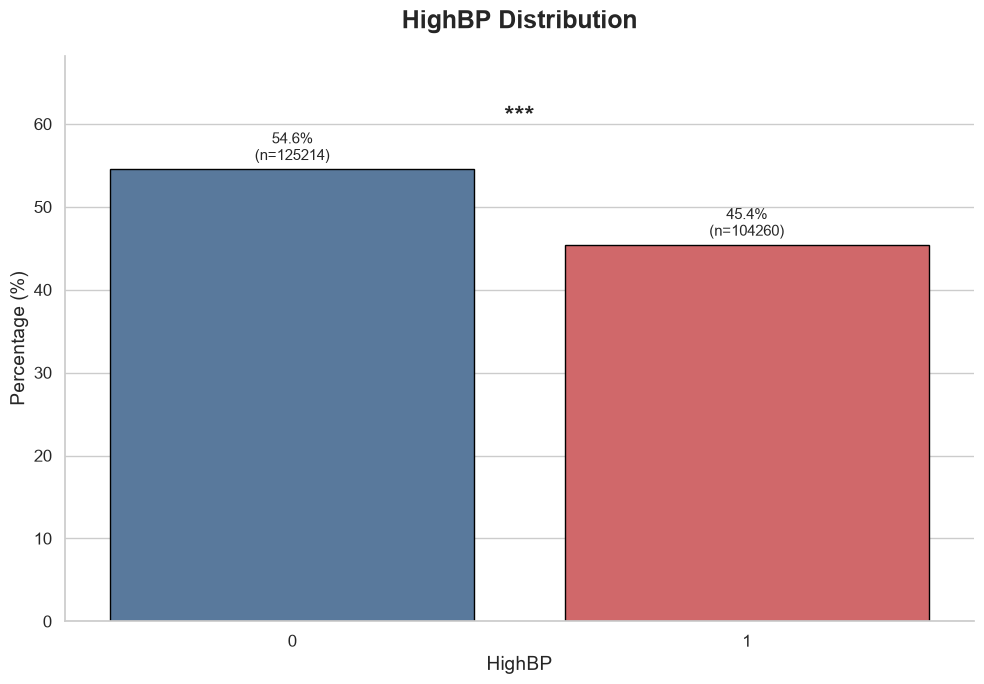

HighChol
Missing values    : 0
Unique categories : 2


,Count,Percentage
HighChol,,
0,128129,55.84
1,101345,44.16


Chi-square : 3126.205
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


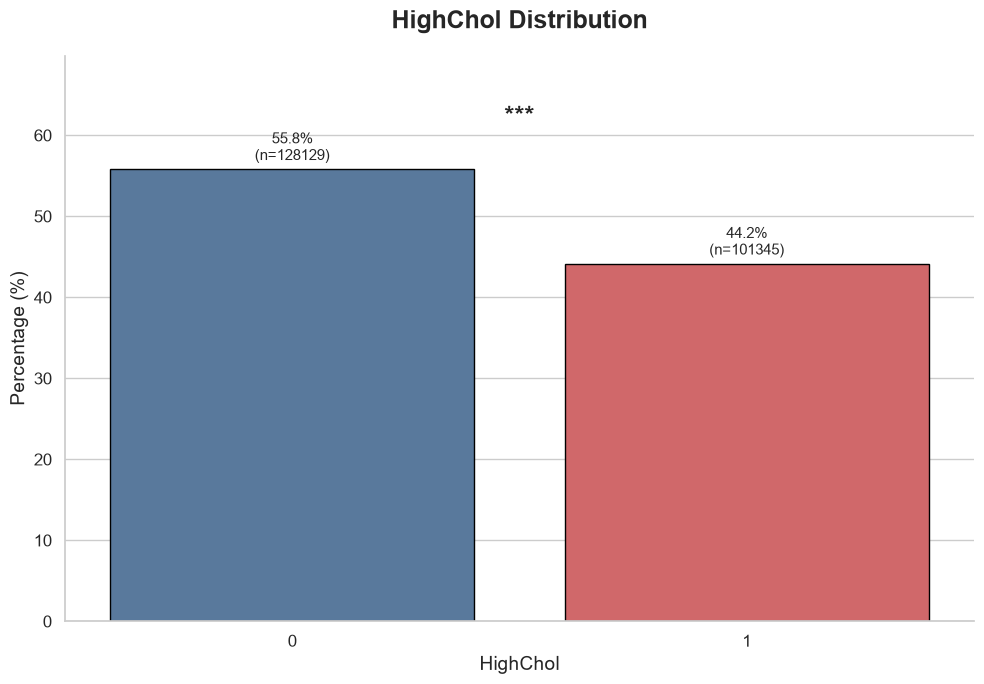

CholCheck
Missing values    : 0
Unique categories : 2


,Count,Percentage
CholCheck,,
0,9298,4.05
1,220176,95.95


Chi-square : 193788.973
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


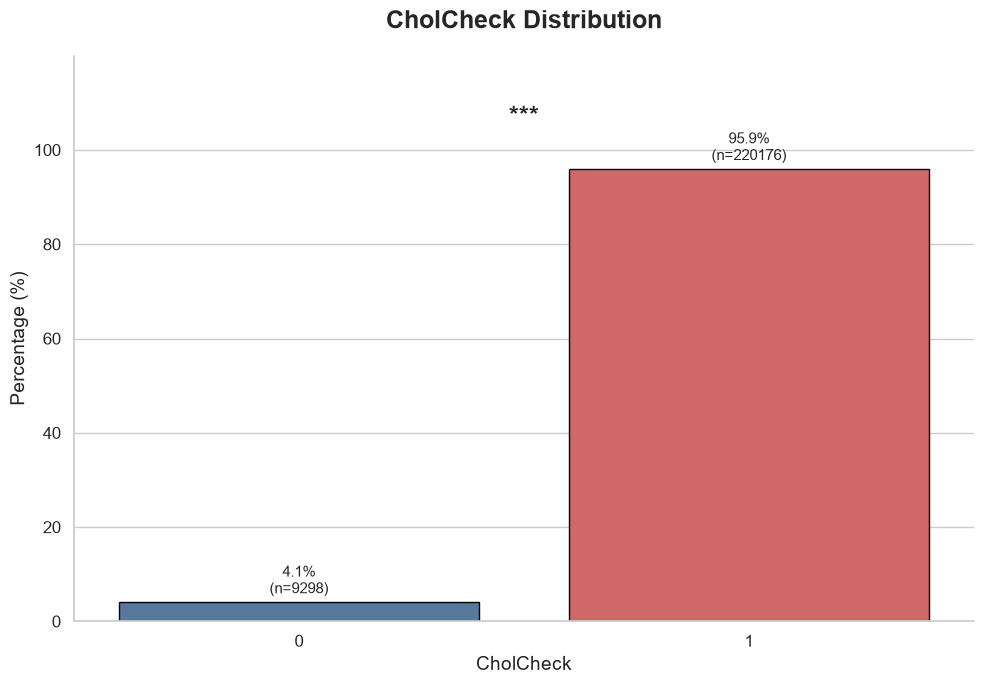

Smoker
Missing values    : 0
Unique categories : 2


,Count,Percentage
Smoker,,
0,122585,53.42
1,106889,46.58


Chi-square : 1073.605
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


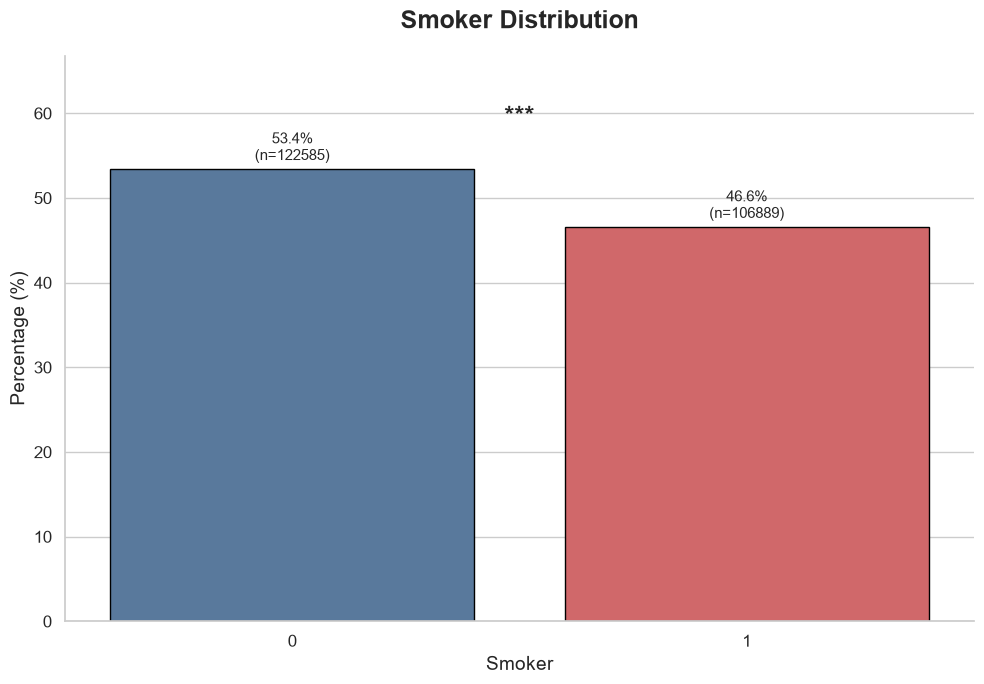

Stroke
Missing values    : 0
Unique categories : 2


,Count,Percentage
Stroke,,
0,219190,95.52
1,10284,4.48


Chi-square : 190181.532
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


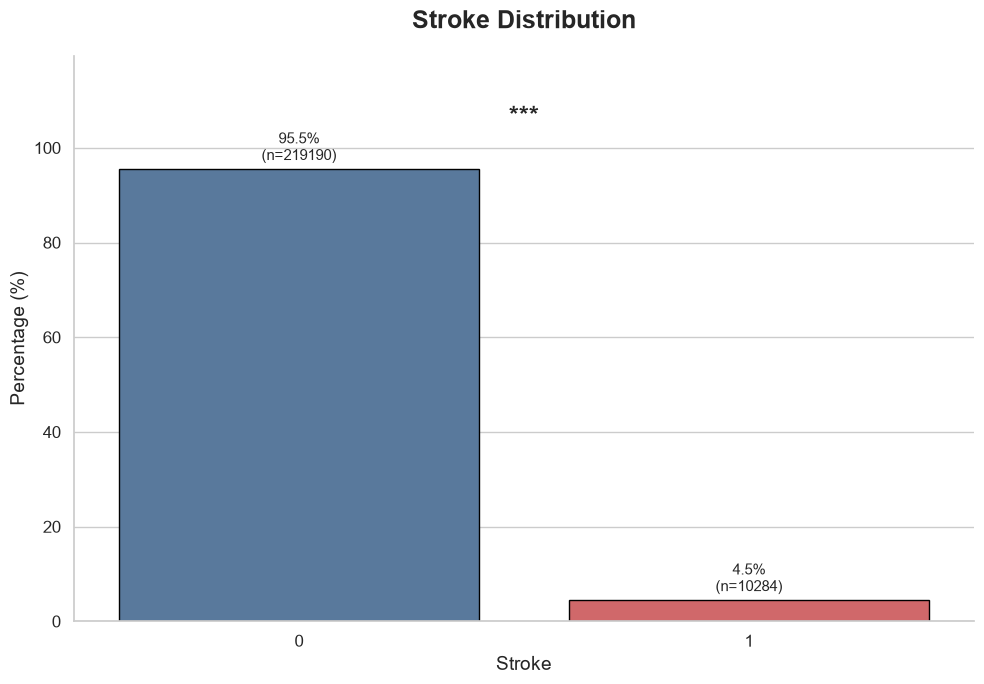

HeartDiseaseorAttack
Missing values    : 0
Unique categories : 2


,Count,Percentage
HeartDiseaseorAttack,,
0,205761,89.67
1,23713,10.33


Chi-square : 144423.657
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


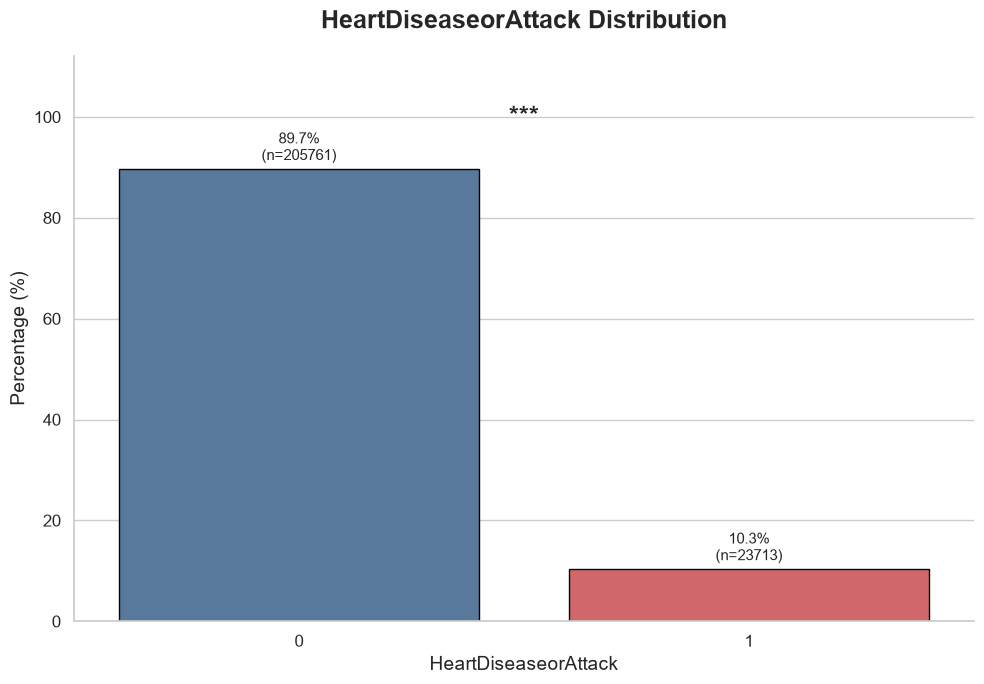

PhysActivity
Missing values    : 0
Unique categories : 2


,Count,Percentage
PhysActivity,,
0,61260,26.7
1,168214,73.3


Chi-square : 49849.474
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


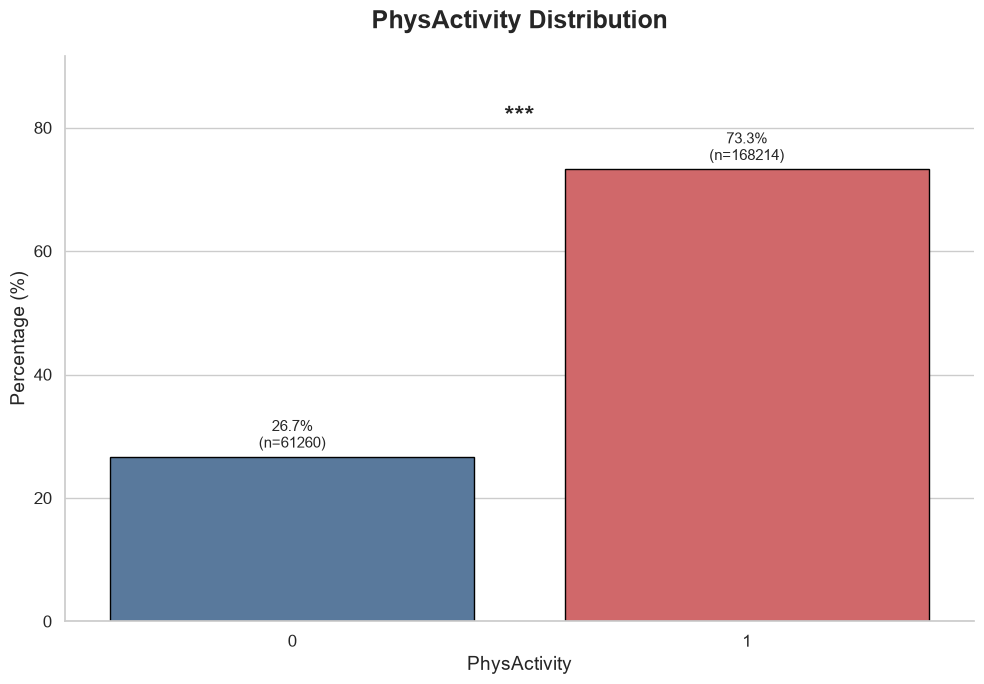

Fruits
Missing values    : 0
Unique categories : 2


,Count,Percentage
Fruits,,
0,88881,38.73
1,140593,61.27


Chi-square : 11653.307
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


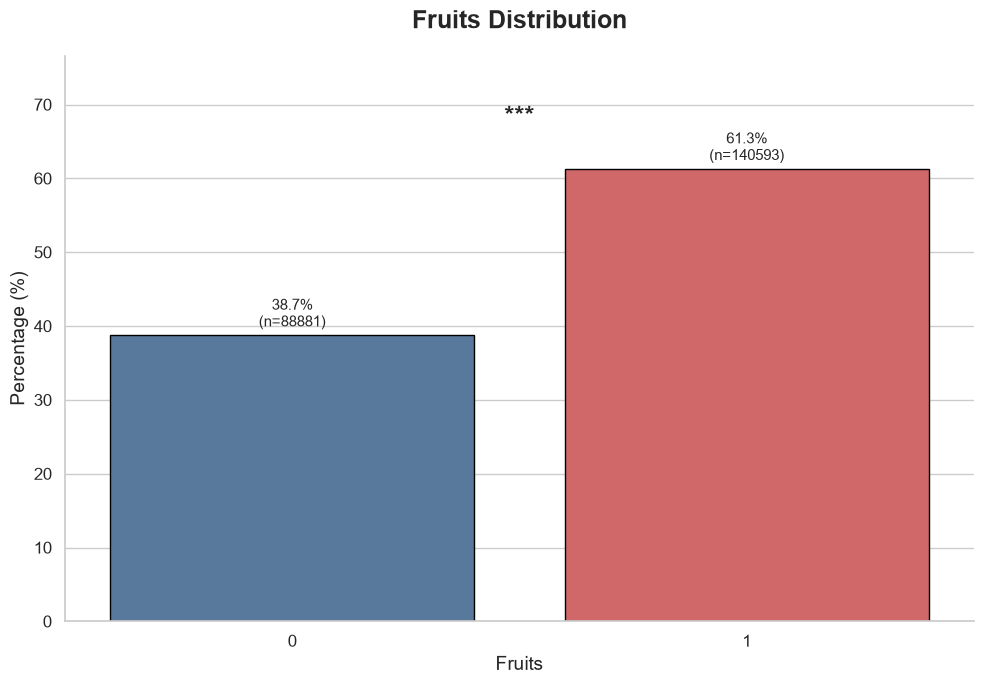

Veggies
Missing values    : 0
Unique categories : 2


,Count,Percentage
Veggies,,
0,47137,20.54
1,182337,79.46


Chi-square : 79656.257
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


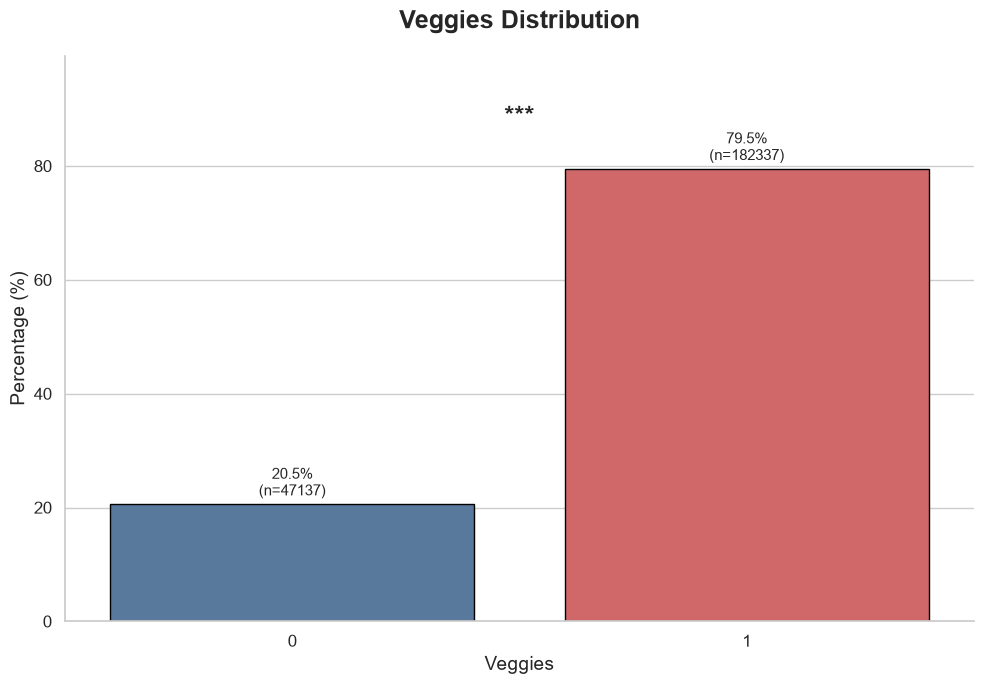

HvyAlcoholConsump
Missing values    : 0
Unique categories : 2


,Count,Percentage
HvyAlcoholConsump,,
0,215524,93.92
1,13950,6.08


Chi-square : 177066.149
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


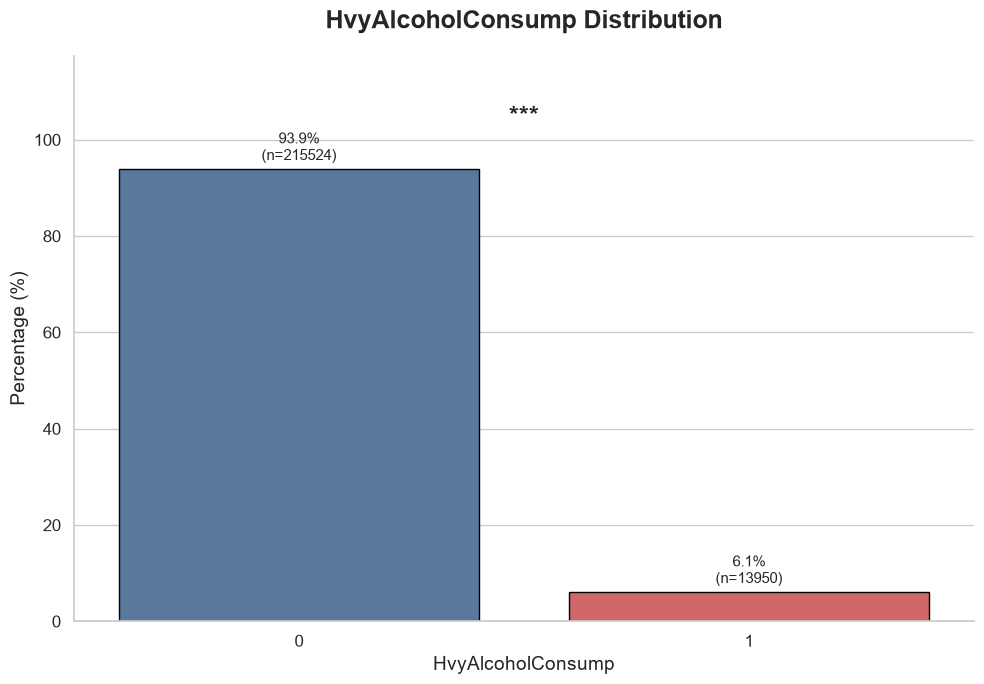

AnyHealthcare
Missing values    : 0
Unique categories : 2


,Count,Percentage
AnyHealthcare,,
0,12389,5.4
1,217085,94.6


Chi-square : 182593.463
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


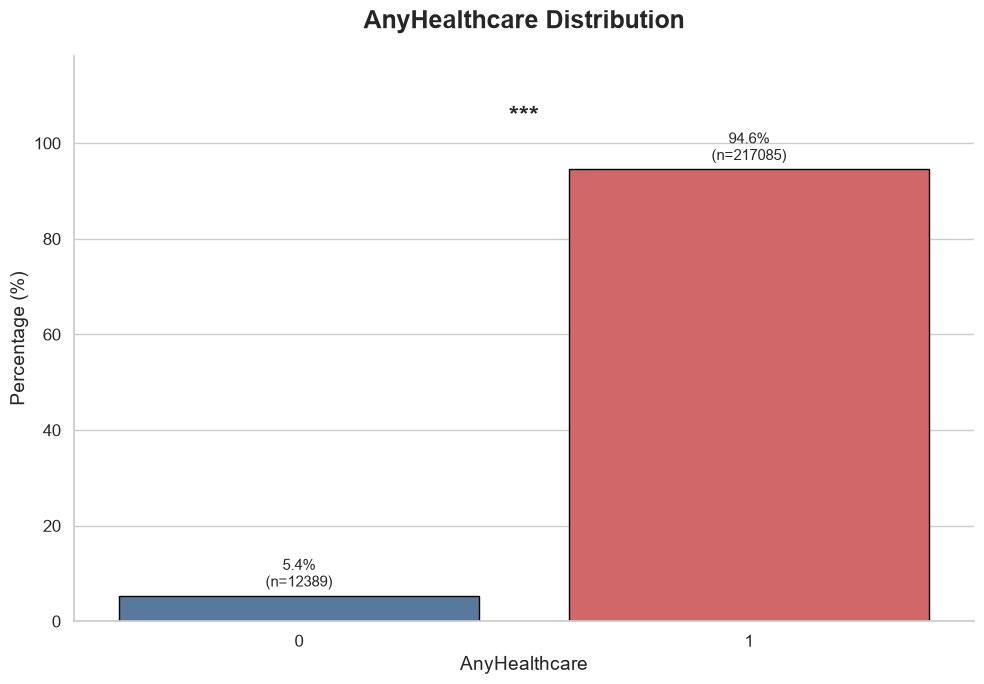

NoDocbcCost
Missing values    : 0
Unique categories : 2


,Count,Percentage
NoDocbcCost,,
0,208151,90.71
1,21323,9.29


Chi-square : 152107.435
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


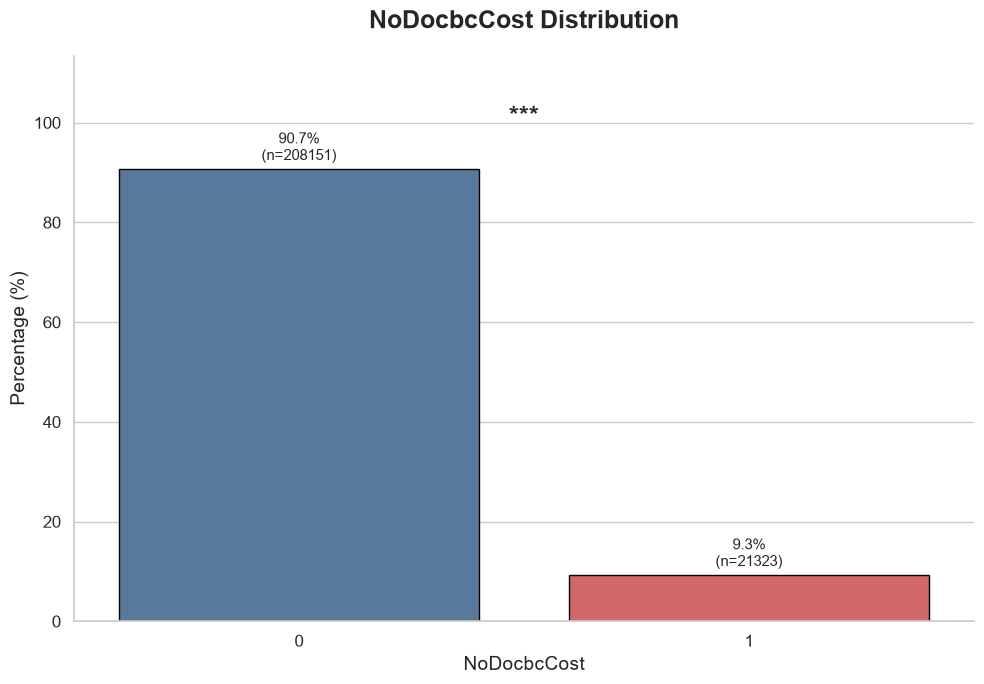

GenHlth
Missing values    : 0
Unique categories : 5


,Count,Percentage
GenHlth,,
1,34854,15.19
2,77365,33.71
3,73632,32.09
4,31545,13.75
5,12078,5.26


Chi-square : 70402.698
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


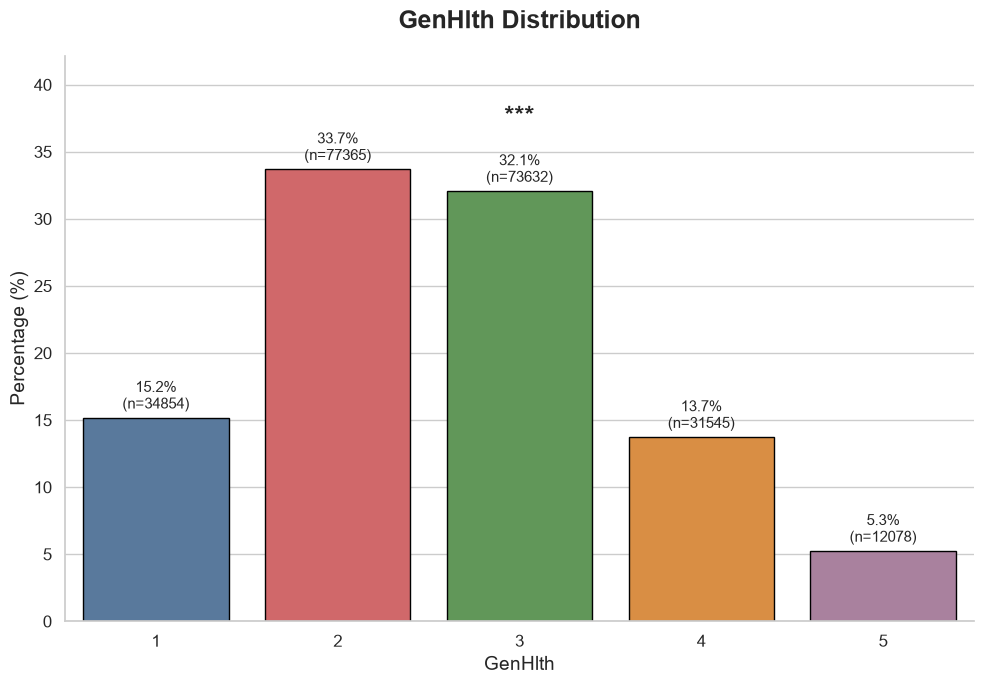

DiffWalk
Missing values    : 0
Unique categories : 2


,Count,Percentage
DiffWalk,,
0,186849,81.42
1,42625,18.58


Chi-square : 90644.527
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


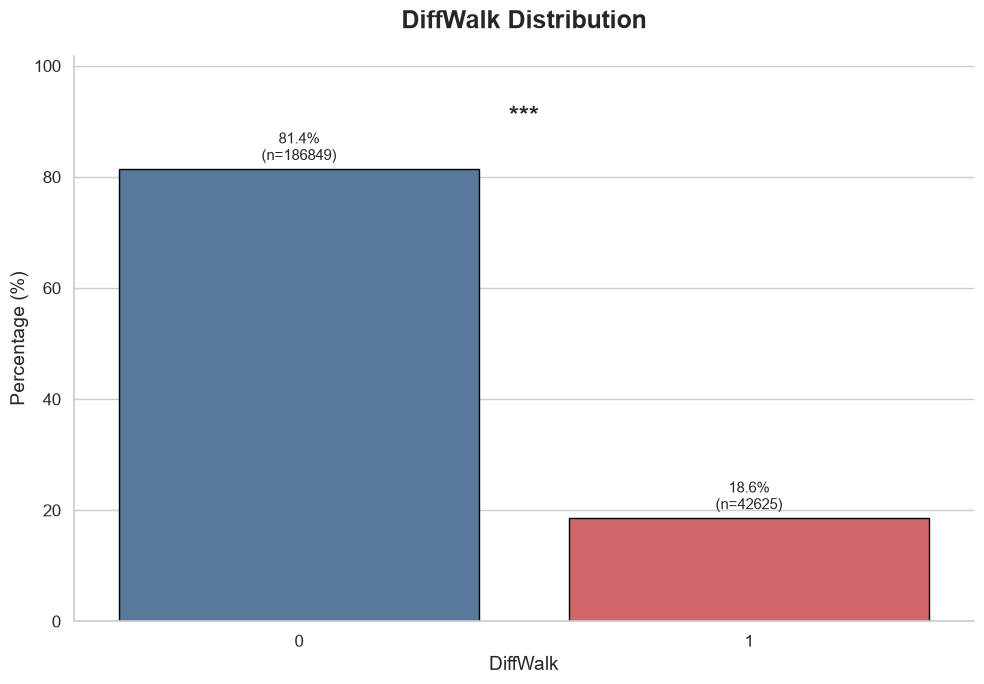

Sex
Missing values    : 0
Unique categories : 2


,Count,Percentage
Sex,,
0,128715,56.09
1,100759,43.91


Chi-square : 3405.780
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


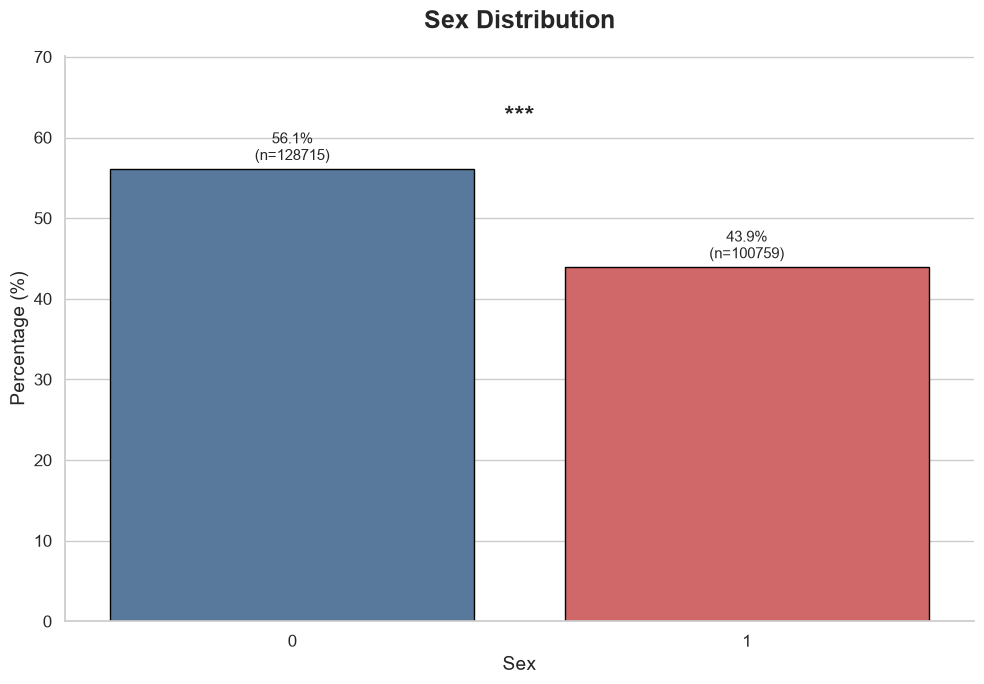

Age
Missing values    : 0
Unique categories : 13


,Count,Percentage
Age,,
1,5511,2.40
10,29093,12.68
11,21993,9.58
12,15379,6.70
13,16791,7.32
2,7064,3.08
3,10023,4.37
4,12229,5.33
5,14040,6.12


Chi-square : 44359.823
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: UserWarning: 
The palette list has fewer values (6) than needed (13) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


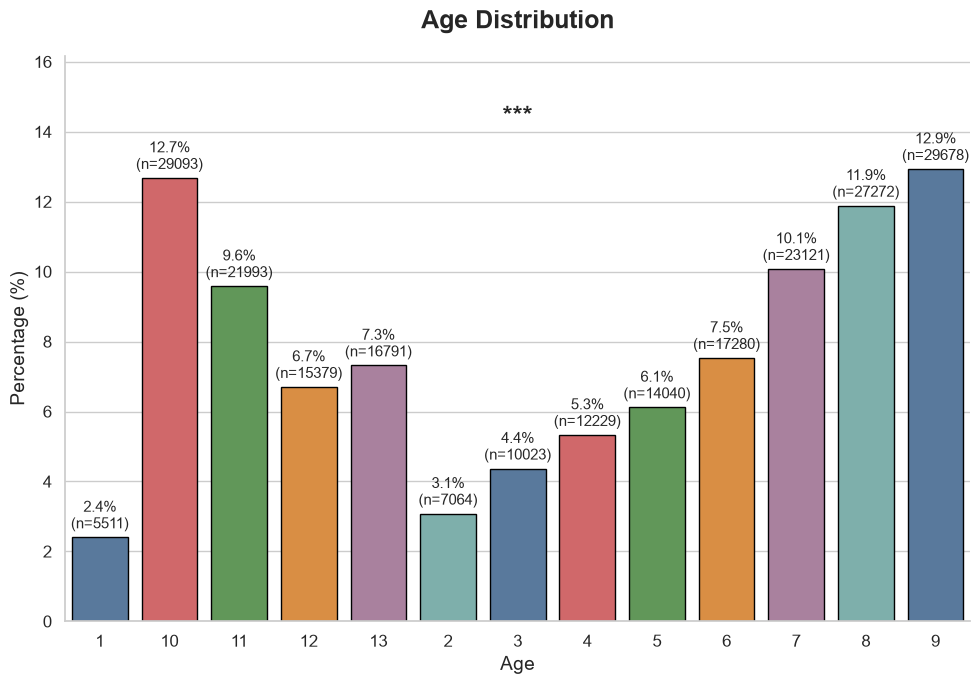

Education
Missing values    : 0
Unique categories : 6


,Count,Percentage
Education,,
1,174,0.08
2,4040,1.76
3,9467,4.13
4,61124,26.64
5,66444,28.95
6,88225,38.45


Chi-square : 189934.955
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


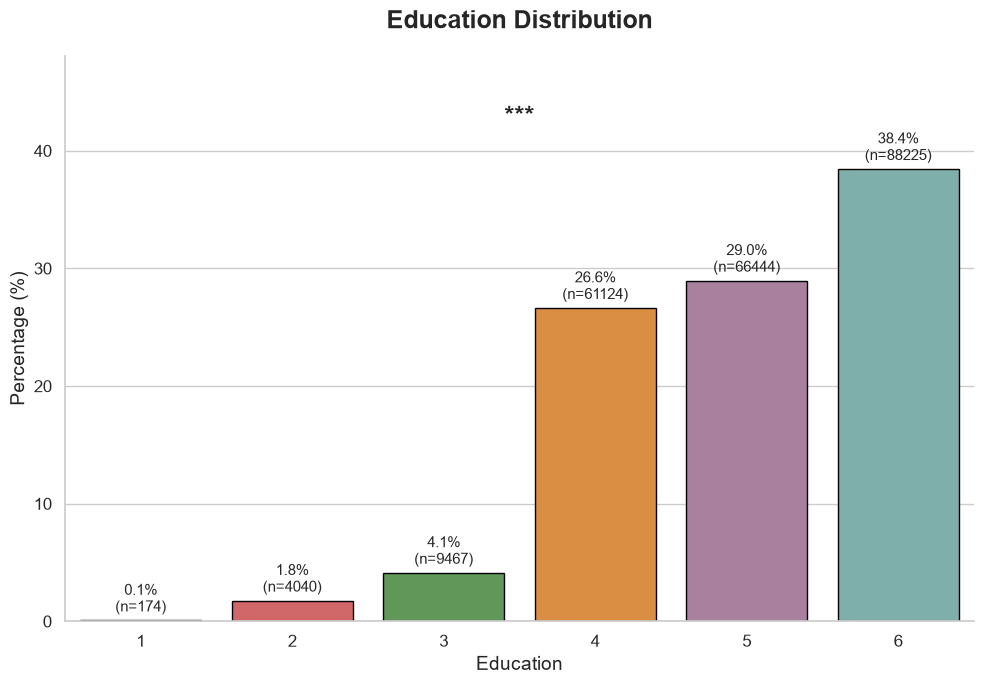

Income
Missing values    : 0
Unique categories : 8


,Count,Percentage
Income,,
1,9791,4.27
2,11756,5.12
3,15920,6.94
4,19953,8.70
5,25326,11.04
6,34957,15.23
7,40131,17.49
8,71640,31.22


Chi-square : 101433.056
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: UserWarning: 
The palette list has fewer values (6) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


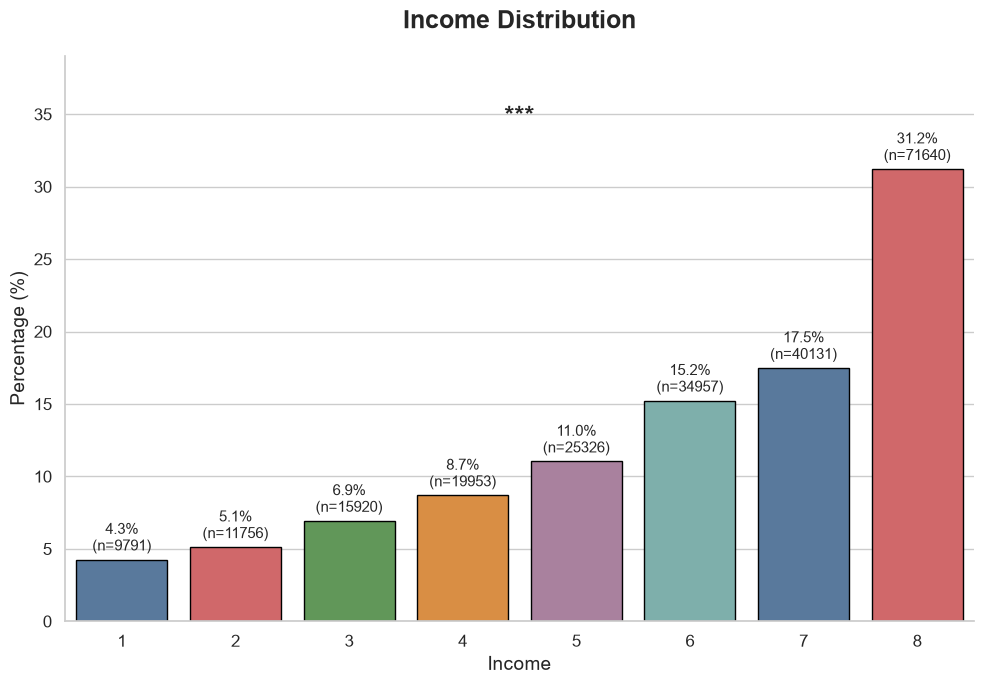

BMI_cat
Missing values    : 0
Unique categories : 4


,Count,Percentage
BMI_cat,,
Underweight,3052,1.33
Normal weight,73635,32.09
Overweight,81414,35.48
Obese,71373,31.10


Chi-square : 69536.301
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


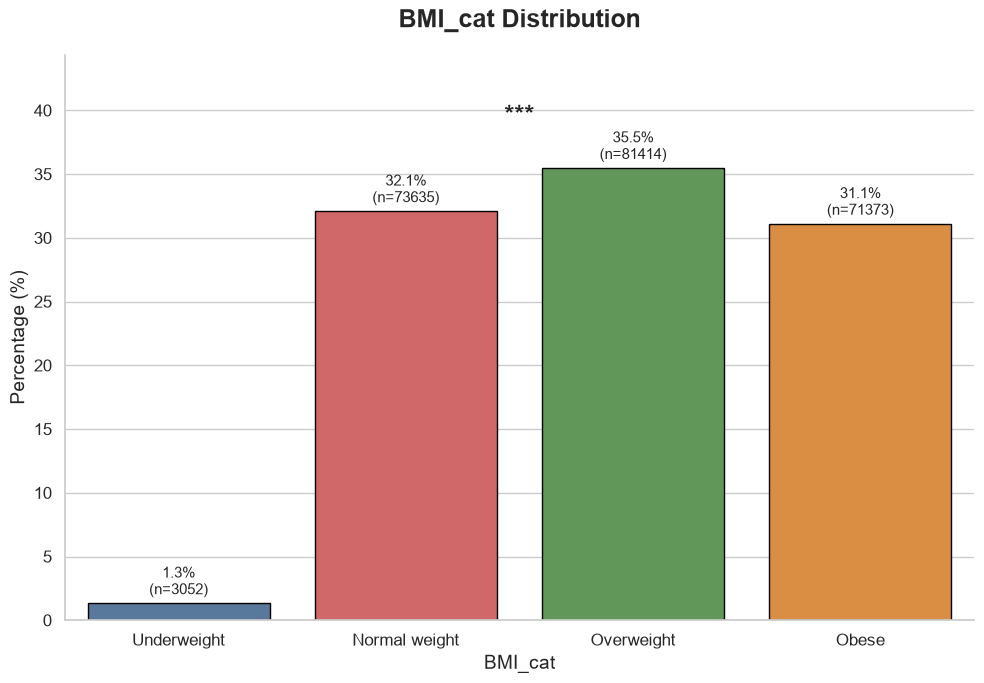

MentHlth_cat
Missing values    : 0
Unique categories : 4


,Count,Percentage
MentHlth_cat,,
0 days,152325,66.38
1-10 days,52147,22.72
11-20 days,10765,4.69
21-30 days,14237,6.20


Chi-square : 227933.682
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


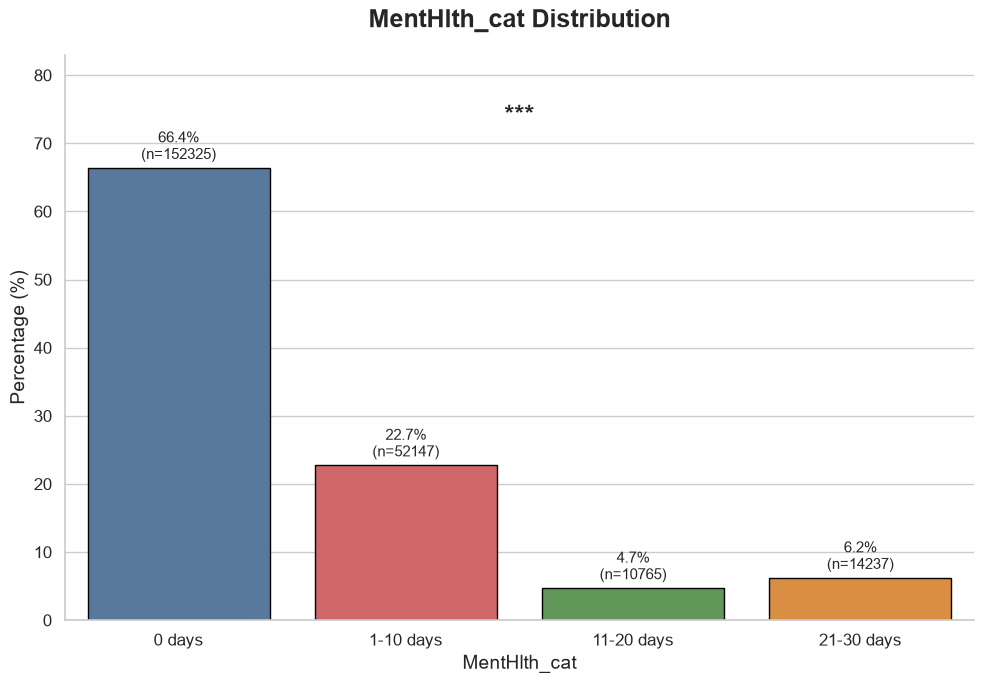

PhysHlth_cat
Missing values    : 0
Unique categories : 4


,Count,Percentage
PhysHlth_cat,,
0 days,136578,59.52
1-10 days,58550,25.51
11-20 days,11859,5.17
21-30 days,22487,9.80


Chi-square : 166700.793
P-value    : 0.0000
Significance : ***


C:\Users\saifu\AppData\Local\Temp\ipykernel_3216\480327970.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


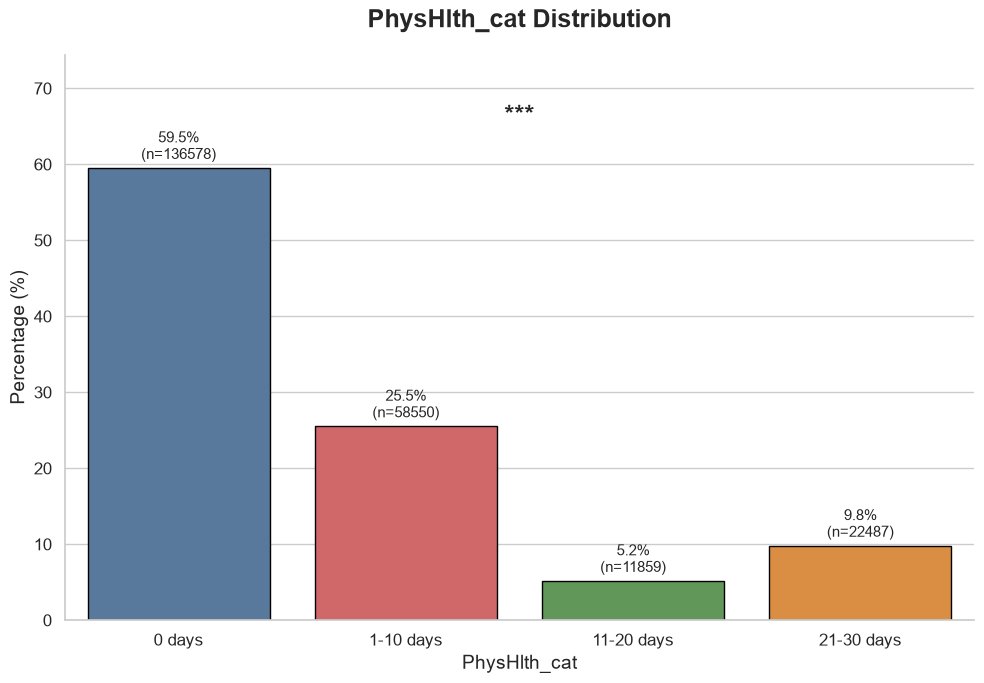

In [27]:
# ===============================================================
# Categorical Variable Analysis
# ===============================================================

for col in categorical_predictors:

    print("=" * 90)
    print(col)
    print("=" * 90)

    # -----------------------------------------------------------
    # Summary statistics
    # -----------------------------------------------------------

    missing = df[col].isna().sum()

    unique = df[col].nunique()

    counts = (

        df[col]

        .value_counts(dropna=False)

        .sort_index()

    )

    percentages = (

        counts

        / counts.sum()

        * 100

    )

    print(f"Missing values    : {missing}")

    print(f"Unique categories : {unique}")

    display(

        pd.DataFrame({

            "Count": counts,

            "Percentage": percentages.round(2)

        })

    )

    # -----------------------------------------------------------
    # Chi-square Goodness-of-Fit Test
    # -----------------------------------------------------------

    expected = np.repeat(

        counts.sum() / len(counts),

        len(counts)

    )

    chi2, p = chisquare(

        f_obs=counts.values,

        f_exp=expected

    )

    annotation = significance_label(p)

    print(f"Chi-square : {chi2:.3f}")

    print(f"P-value    : {p:.4f}")

    print(f"Significance : {annotation}")

    # -----------------------------------------------------------
    # Store summary
    # -----------------------------------------------------------

    for category, count, pct in zip(

        counts.index,

        counts.values,

        percentages.values

    ):

        categorical_summary.append({

            "Variable": col,

            "Category": category,

            "Count": count,

            "Percentage": round(pct, 2),

            "Chi_square": round(chi2, 3),

            "P_value": p,

            "Significance": annotation

        })

    # -----------------------------------------------------------
    # Figure
    # -----------------------------------------------------------

    fig, ax = plt.subplots(

        figsize=(10, 7)

    )

    sns.barplot(

        x=percentages.index.astype(str),

        y=percentages.values,

        palette=categorical_palette[:len(percentages)],

        edgecolor="black",

        ax=ax

    )

    ax.set_xlabel(col)

    ax.set_ylabel("Percentage (%)")

    ax.set_title(

        f"{col} Distribution",

        fontweight="bold",

        pad=20

    )

    # -----------------------------------------------------------
    # Labels
    # -----------------------------------------------------------

    for i, (count, pct) in enumerate(

        zip(counts, percentages)

    ):

        ax.text(

            i,

            pct + percentages.max() * 0.02,

            f"{pct:.1f}%\n(n={count})",

            ha="center",

            fontsize=11

        )

    # -----------------------------------------------------------
    # Significance
    # -----------------------------------------------------------

    if annotation != "ns":

        ax.text(

            (len(percentages) - 1) / 2,

            percentages.max() * 1.10,

            annotation,

            ha="center",

            fontsize=18,

            fontweight="bold"

        )

    ax.set_ylim(

        0,

        percentages.max() * 1.25

    )

    sns.despine()

    plt.tight_layout()

    save_figure(

        fig,

        CATEGORICAL_DIR,

        f"{col}.png"

    )

    plt.show()

    plt.close()

In [28]:
# ===============================================================
# Categorical Summary Table
# ===============================================================

categorical_summary = pd.DataFrame(

    categorical_summary

)

display(

    categorical_summary.head()

)

,Variable,Category,Count,Percentage,Chi_square,P_value,Significance
0,HighBP,0,125214,54.57,1913.376,0.0,***
1,HighBP,1,104260,45.43,1913.376,0.0,***
2,HighChol,0,128129,55.84,3126.205,0.0,***
3,HighChol,1,101345,44.16,3126.205,0.0,***
4,CholCheck,0,9298,4.05,193788.973,0.0,***


In [29]:
# ===============================================================
# Save Categorical Summary
# ===============================================================

categorical_summary.to_csv(

    SUMMARY_DIR / "categorical_summary.csv",

    index=False

)

print(

    "Categorical summary saved successfully."

)

Categorical summary saved successfully.


In [30]:
# ===============================================================
# Continuous Variables
# ===============================================================

print("=" * 70)
print("Continuous Variables")
print("=" * 70)

print(continuous_cols)

Continuous Variables
['BMI', 'MentHlth', 'PhysHlth']


BMI


,Variable,N,Missing,Mean,SD,Median,IQR,Minimum,Maximum
0,BMI,229474,0,28.688,6.789,27.0,8.0,12,98


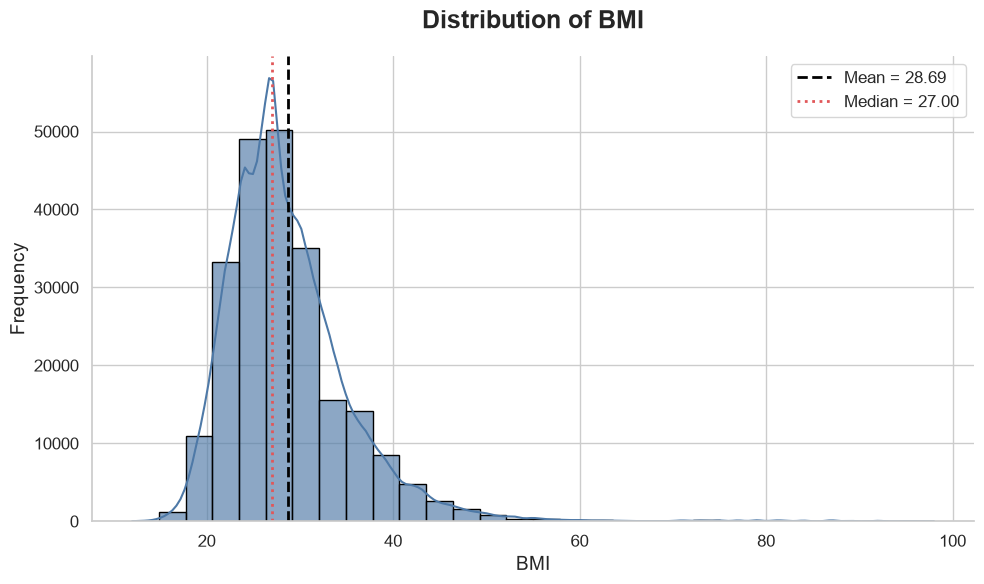

MentHlth


,Variable,N,Missing,Mean,SD,Median,IQR,Minimum,Maximum
0,MentHlth,229474,0,3.51,7.718,0.0,2.0,0,30


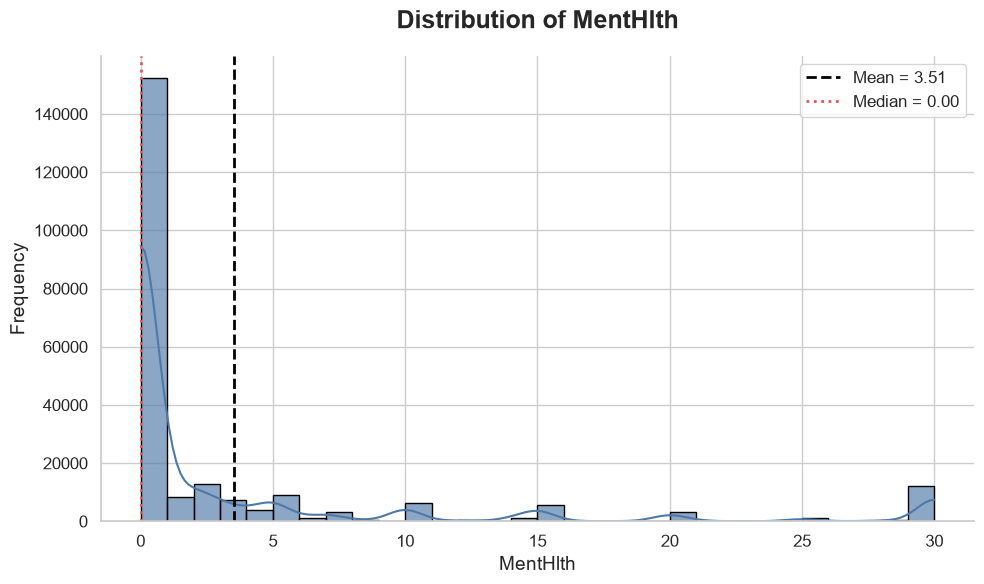

PhysHlth


,Variable,N,Missing,Mean,SD,Median,IQR,Minimum,Maximum
0,PhysHlth,229474,0,4.681,9.051,0.0,4.0,0,30


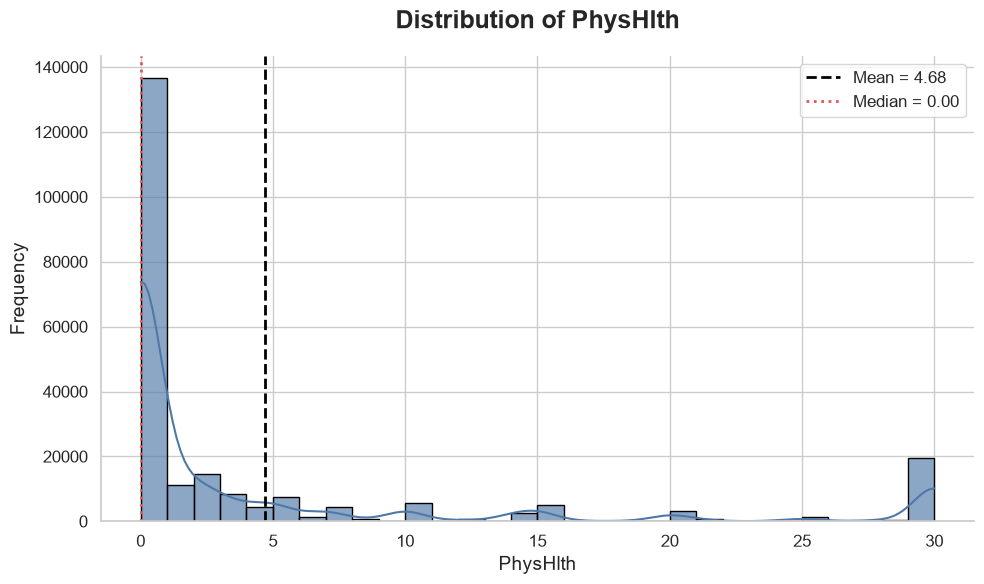

In [31]:
# ===============================================================
# Continuous Variable Analysis
# ===============================================================

for col in continuous_cols:

    print("=" * 90)
    print(col)
    print("=" * 90)

    # -----------------------------------------------------------
    # Summary Statistics
    # -----------------------------------------------------------

    summary = {

        "Variable": col,

        "N": df[col].count(),

        "Missing": df[col].isna().sum(),

        "Mean": df[col].mean(),

        "SD": df[col].std(),

        "Median": df[col].median(),

        "IQR": df[col].quantile(0.75) - df[col].quantile(0.25),

        "Minimum": df[col].min(),

        "Maximum": df[col].max()

    }

    continuous_summary.append(summary)

    display(

        pd.DataFrame([summary]).round(3)

    )

    # -----------------------------------------------------------
    # Figure
    # -----------------------------------------------------------

    fig, ax = plt.subplots(

        figsize=(10, 6)

    )

    sns.histplot(

        data=df,

        x=col,

        bins=30,

        kde=True,

        color="#4E79A7",

        alpha=0.65,

        edgecolor="black",

        ax=ax

    )

    # Mean

    mean_value = df[col].mean()

    ax.axvline(

        mean_value,

        color="black",

        linestyle="--",

        linewidth=2,

        label=f"Mean = {mean_value:.2f}"

    )

    # Median

    median_value = df[col].median()

    ax.axvline(

        median_value,

        color="#E15759",

        linestyle=":",

        linewidth=2,

        label=f"Median = {median_value:.2f}"

    )

    ax.set_title(

        f"Distribution of {col}",

        fontweight="bold",

        pad=20

    )

    ax.set_xlabel(col)

    ax.set_ylabel("Frequency")

    ax.legend()

    sns.despine()

    plt.tight_layout()

    save_figure(

        fig,

        CONTINUOUS_DIR,

        f"{col}.png"

    )

    plt.show()

    plt.close()

In [32]:
# ===============================================================
# Continuous Summary Table
# ===============================================================

continuous_summary = pd.DataFrame(

    continuous_summary

)

display(

    continuous_summary.round(3)

)

,Variable,N,Missing,Mean,SD,Median,IQR,Minimum,Maximum
0,BMI,229474,0,28.688,6.789,27.0,8.0,12,98
1,MentHlth,229474,0,3.510,7.718,0.0,2.0,0,30
2,PhysHlth,229474,0,4.681,9.051,0.0,4.0,0,30


In [33]:
# ===============================================================
# Save Continuous Summary
# ===============================================================

continuous_summary.to_csv(

    SUMMARY_DIR / "continuous_summary.csv",

    index=False

)

print("=" * 70)
print("Continuous summary saved successfully.")
print("=" * 70)

Continuous summary saved successfully.


HighBP vs Diabetes_binary


Diabetes_binary,0,1
HighBP,,
0,116522,8692
1,77855,26405


Chi-square : 14840.422
P-value    : 0.0000
Cramer's V : 0.254


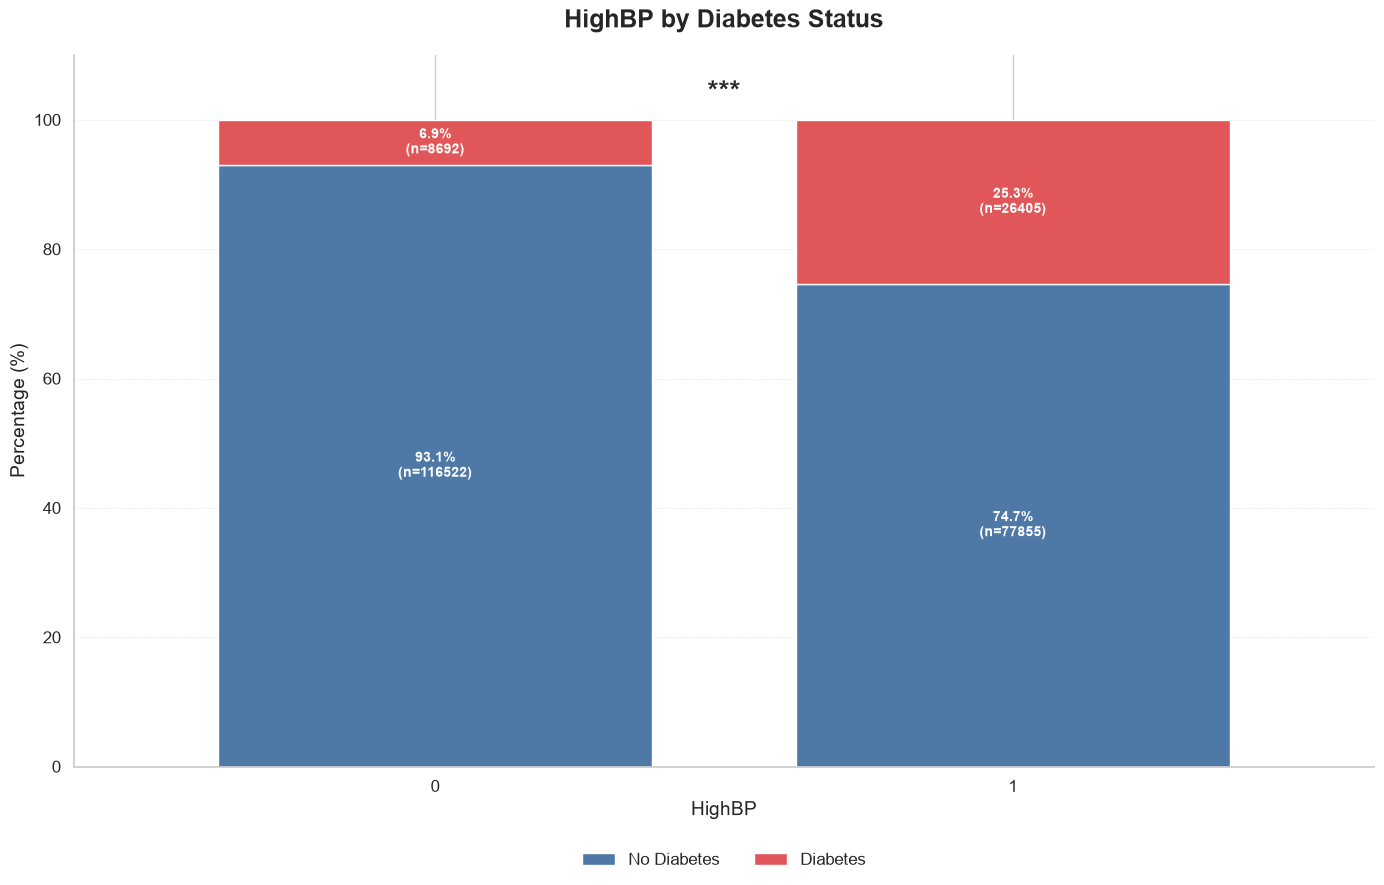

HighChol vs Diabetes_binary


Diabetes_binary,0,1
HighChol,,
0,116528,11601
1,77849,23496


Chi-square : 8719.657
P-value    : 0.0000
Cramer's V : 0.195


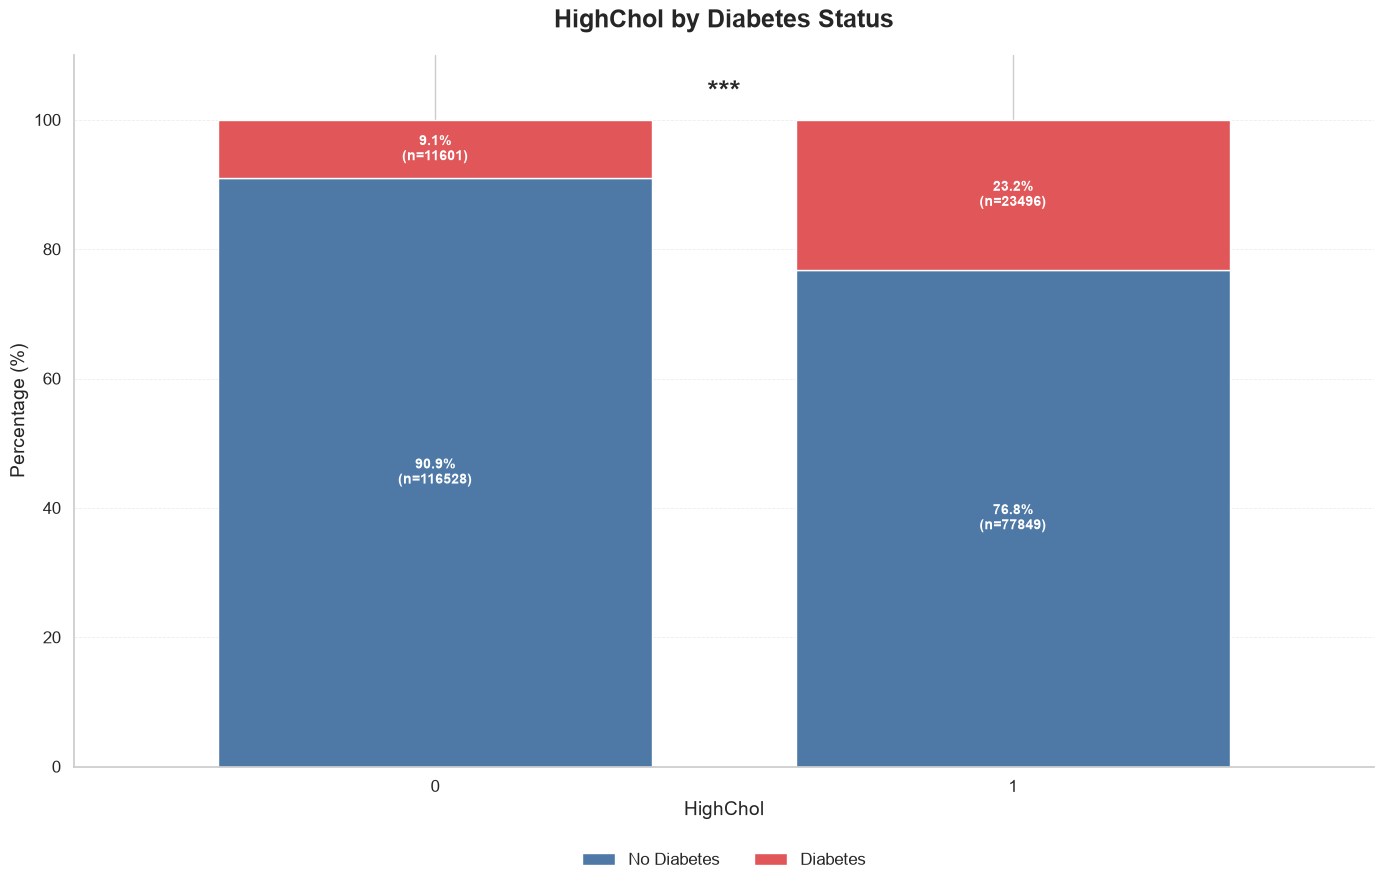

CholCheck vs Diabetes_binary


Diabetes_binary,0,1
CholCheck,,
0,9057,241
1,185320,34856


Chi-square : 1205.929
P-value    : 0.0000
Cramer's V : 0.072


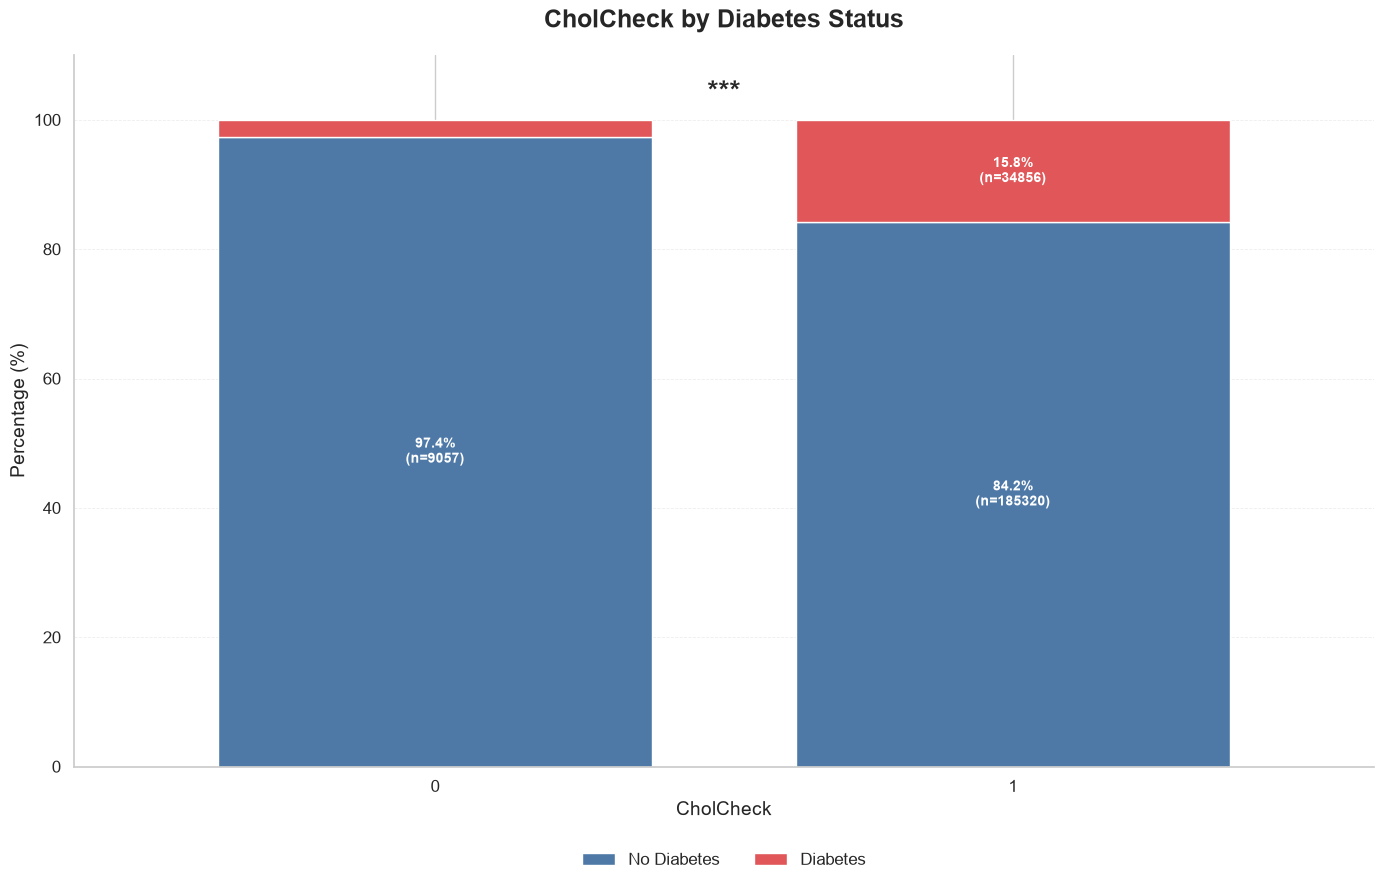

Smoker vs Diabetes_binary


Diabetes_binary,0,1
Smoker,,
0,105711,16874
1,88666,18223


Chi-square : 474.898
P-value    : 0.0000
Cramer's V : 0.045


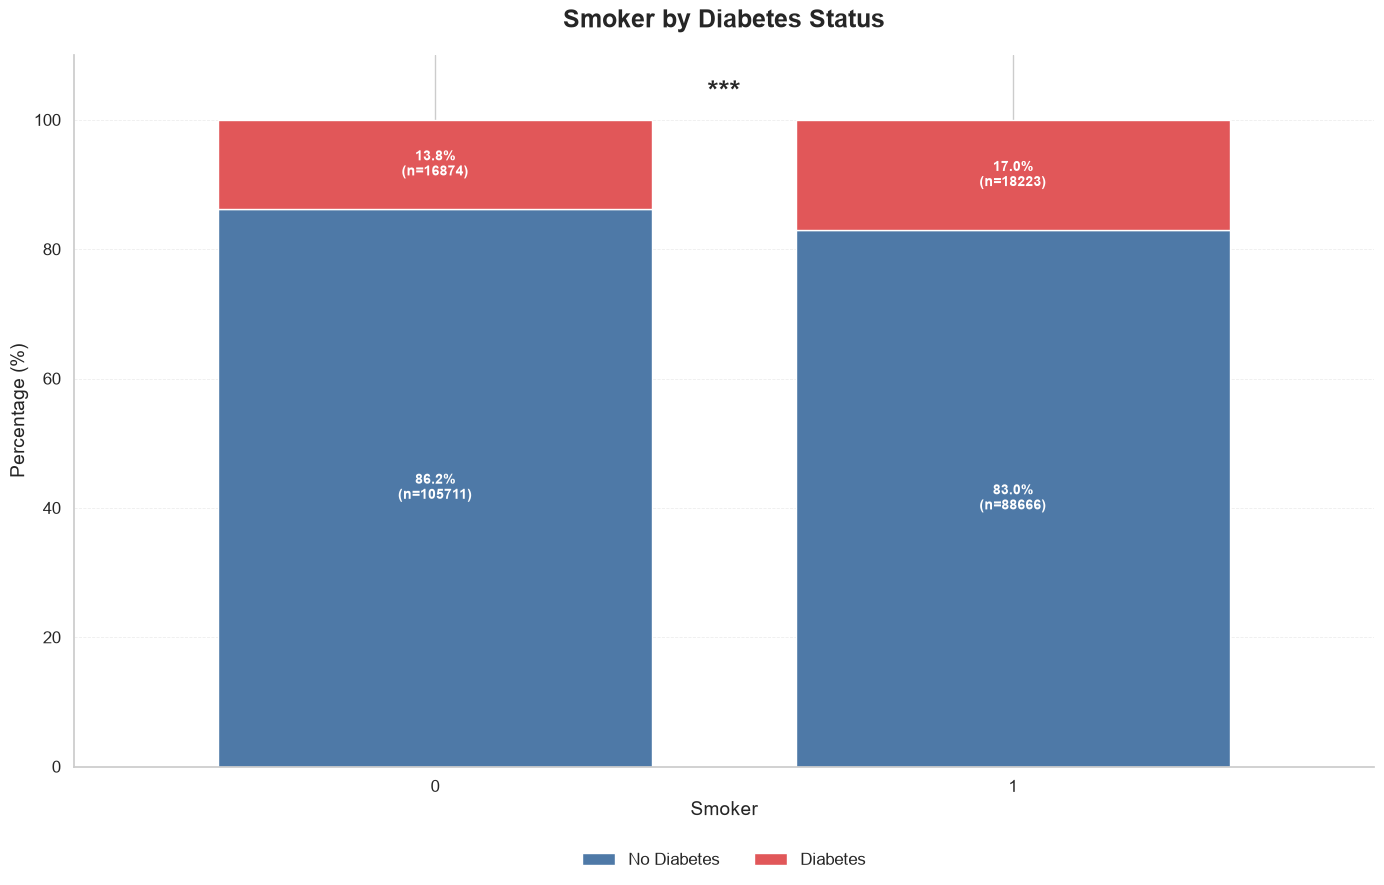

Stroke vs Diabetes_binary


Diabetes_binary,0,1
Stroke,,
0,187361,31829
1,7016,3268


Chi-square : 2256.534
P-value    : 0.0000
Cramer's V : 0.099


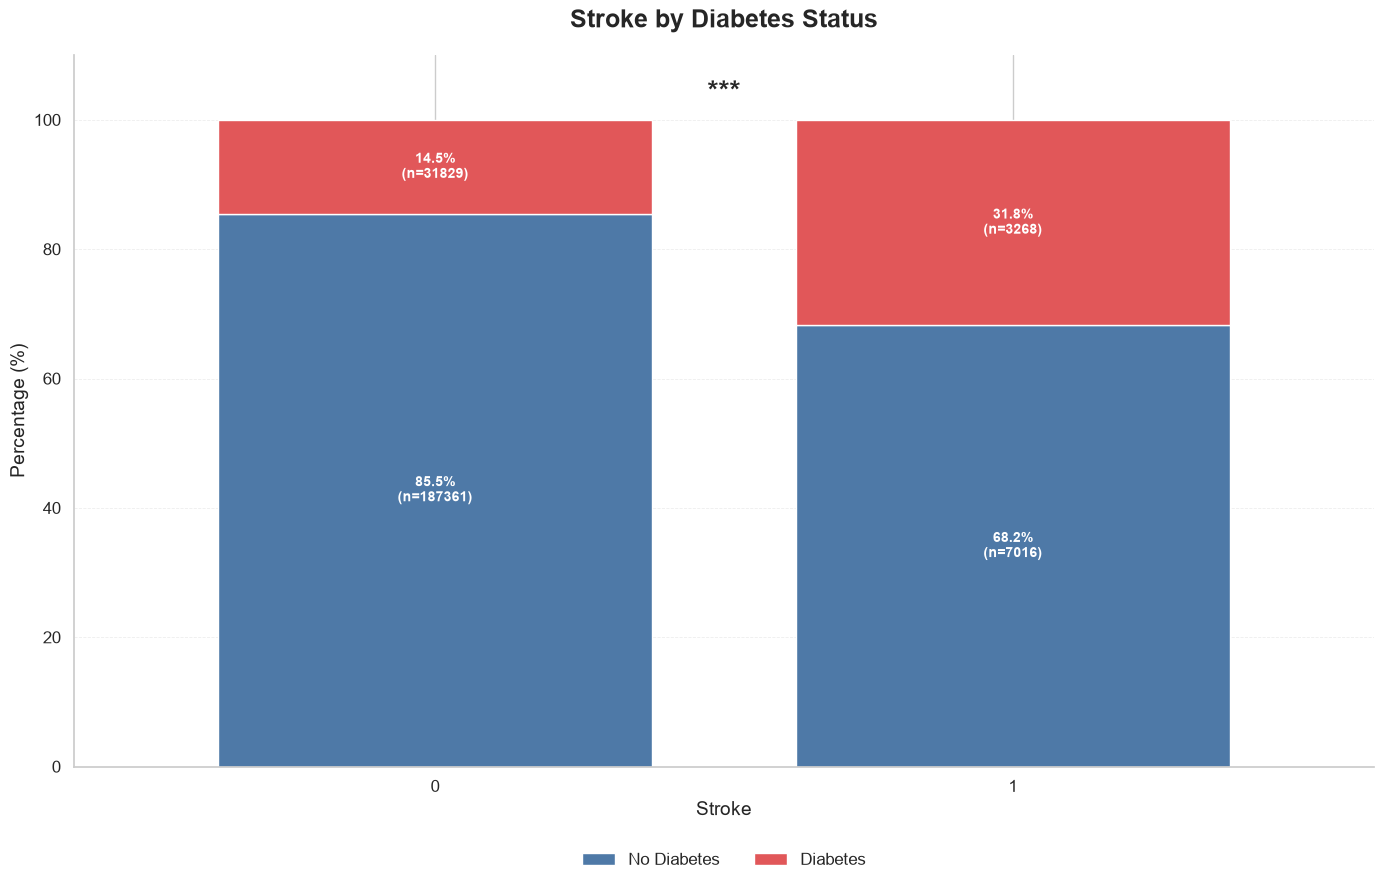

HeartDiseaseorAttack vs Diabetes_binary


Diabetes_binary,0,1
HeartDiseaseorAttack,,
0,178520,27241
1,15857,7856


Chi-square : 6491.586
P-value    : 0.0000
Cramer's V : 0.168


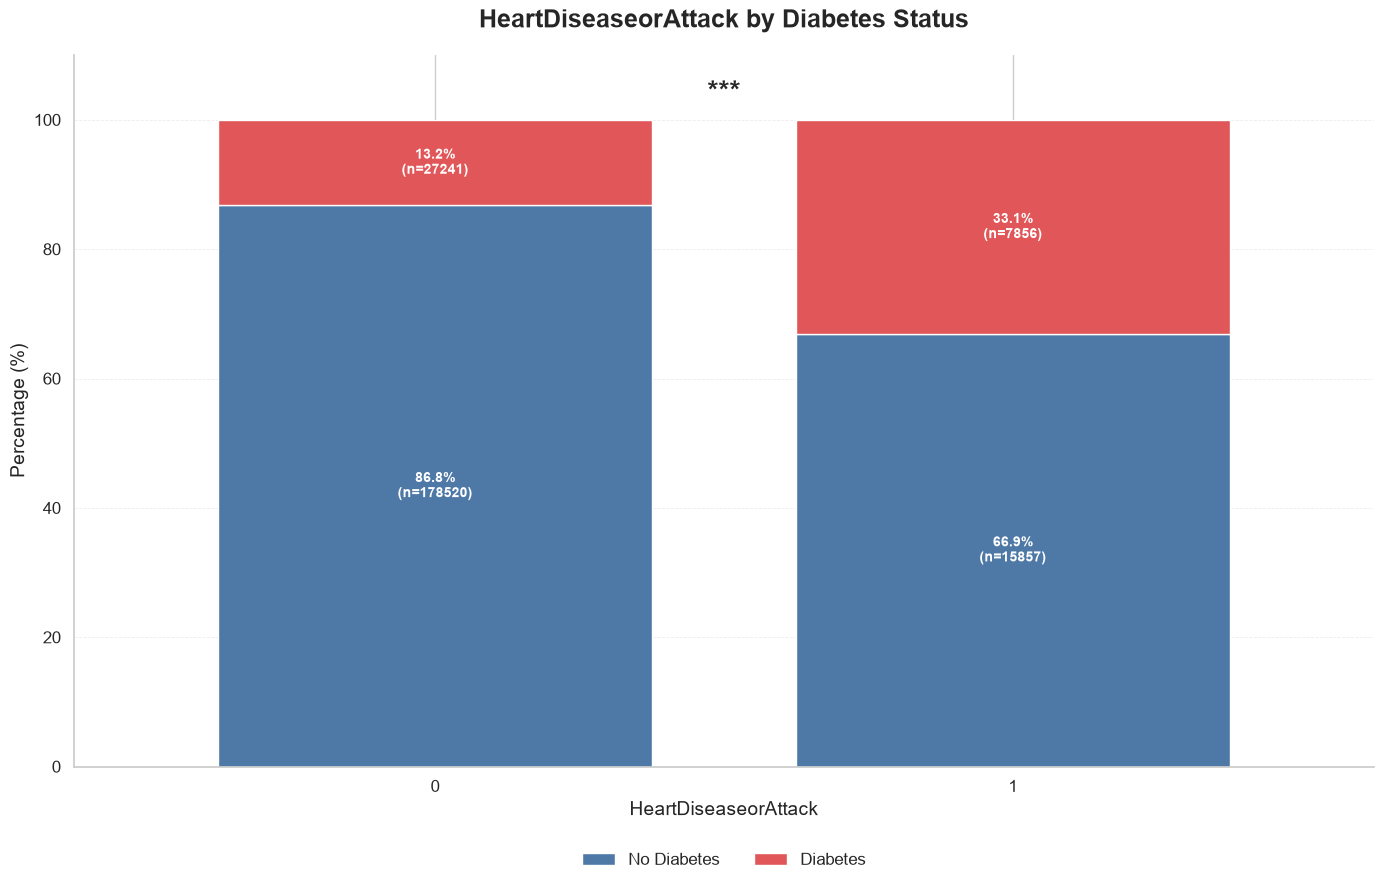

PhysActivity vs Diabetes_binary


Diabetes_binary,0,1
PhysActivity,,
0,48222,13038
1,146155,22059


Chi-square : 2312.704
P-value    : 0.0000
Cramer's V : 0.100


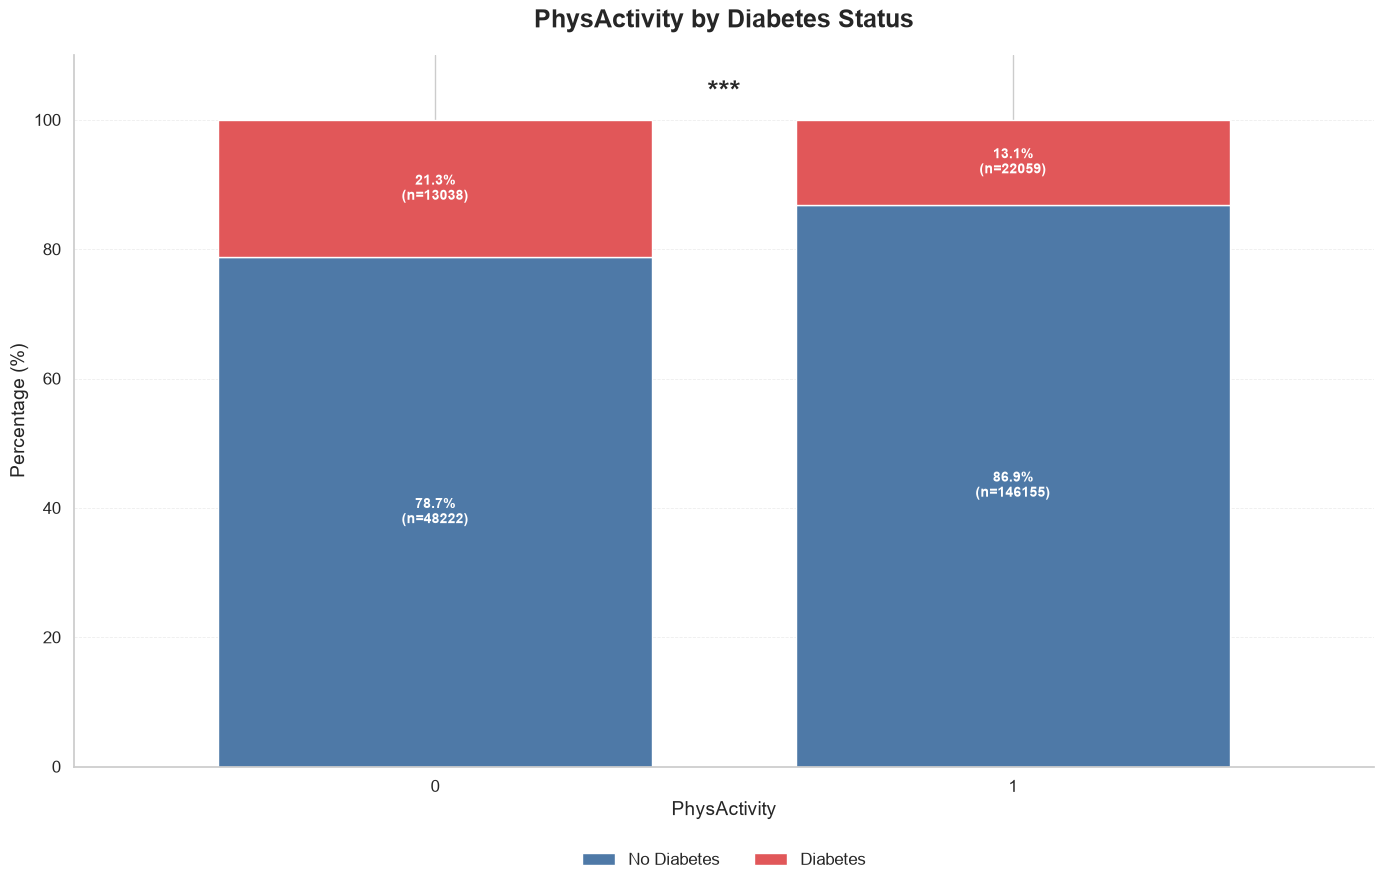

Fruits vs Diabetes_binary


Diabetes_binary,0,1
Fruits,,
0,74289,14592
1,120088,20505


Chi-square : 141.055
P-value    : 0.0000
Cramer's V : 0.025


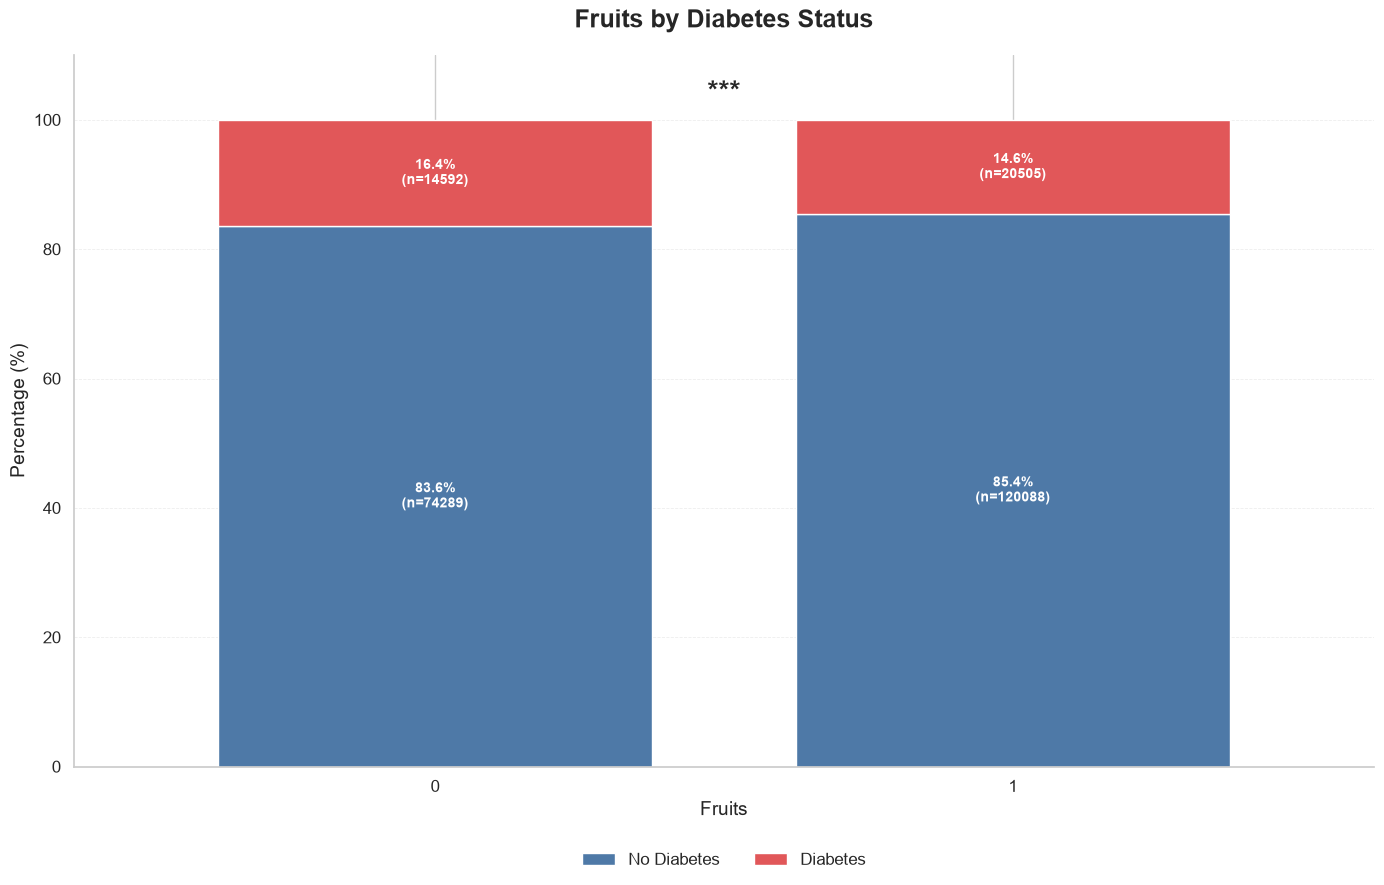

Veggies vs Diabetes_binary


Diabetes_binary,0,1
Veggies,,
0,38535,8602
1,155842,26495


Chi-square : 399.390
P-value    : 0.0000
Cramer's V : 0.042


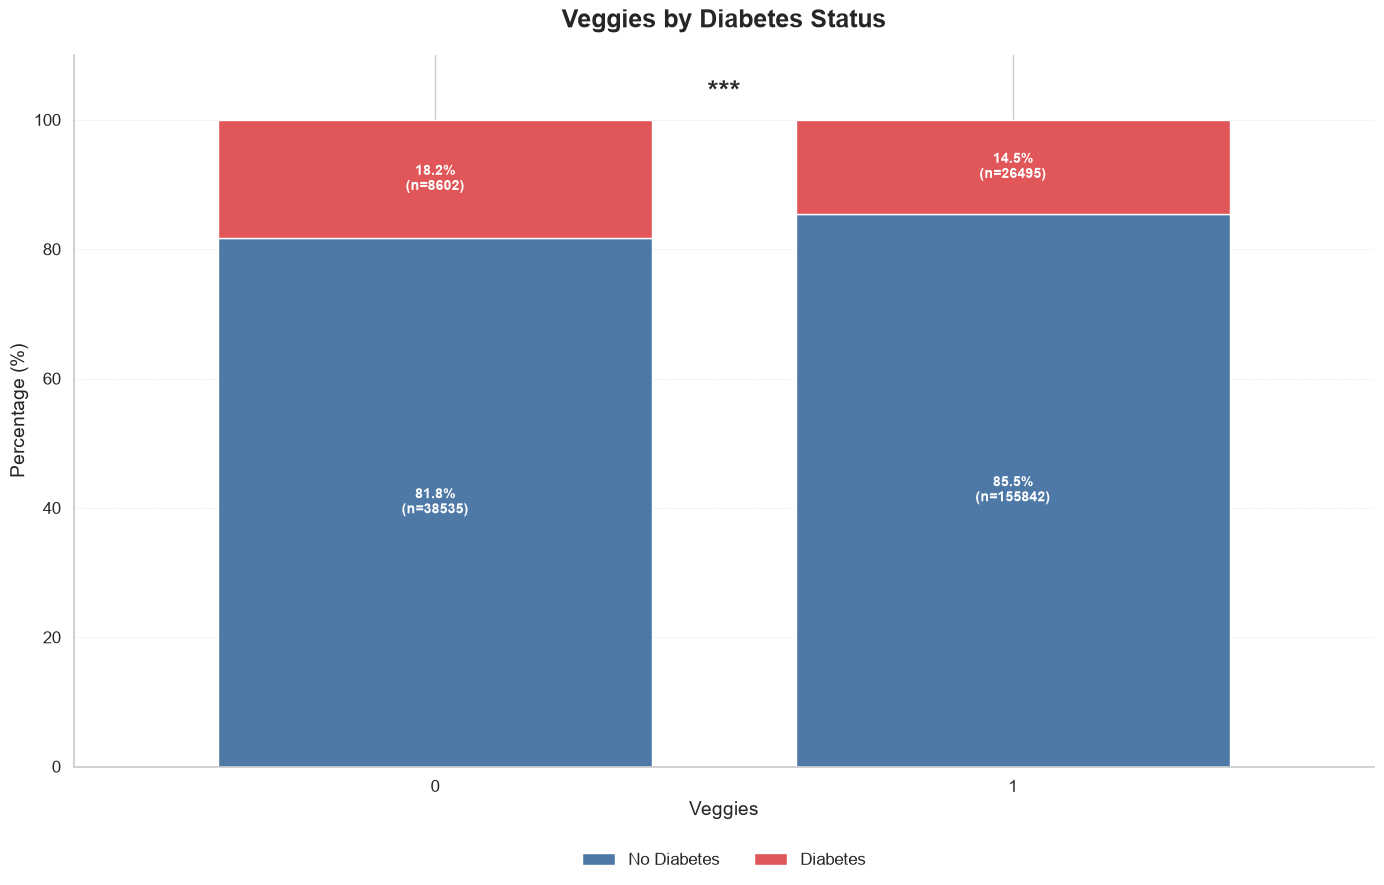

HvyAlcoholConsump vs Diabetes_binary


Diabetes_binary,0,1
HvyAlcoholConsump,,
0,181259,34265
1,13118,832


Chi-square : 997.309
P-value    : 0.0000
Cramer's V : 0.066


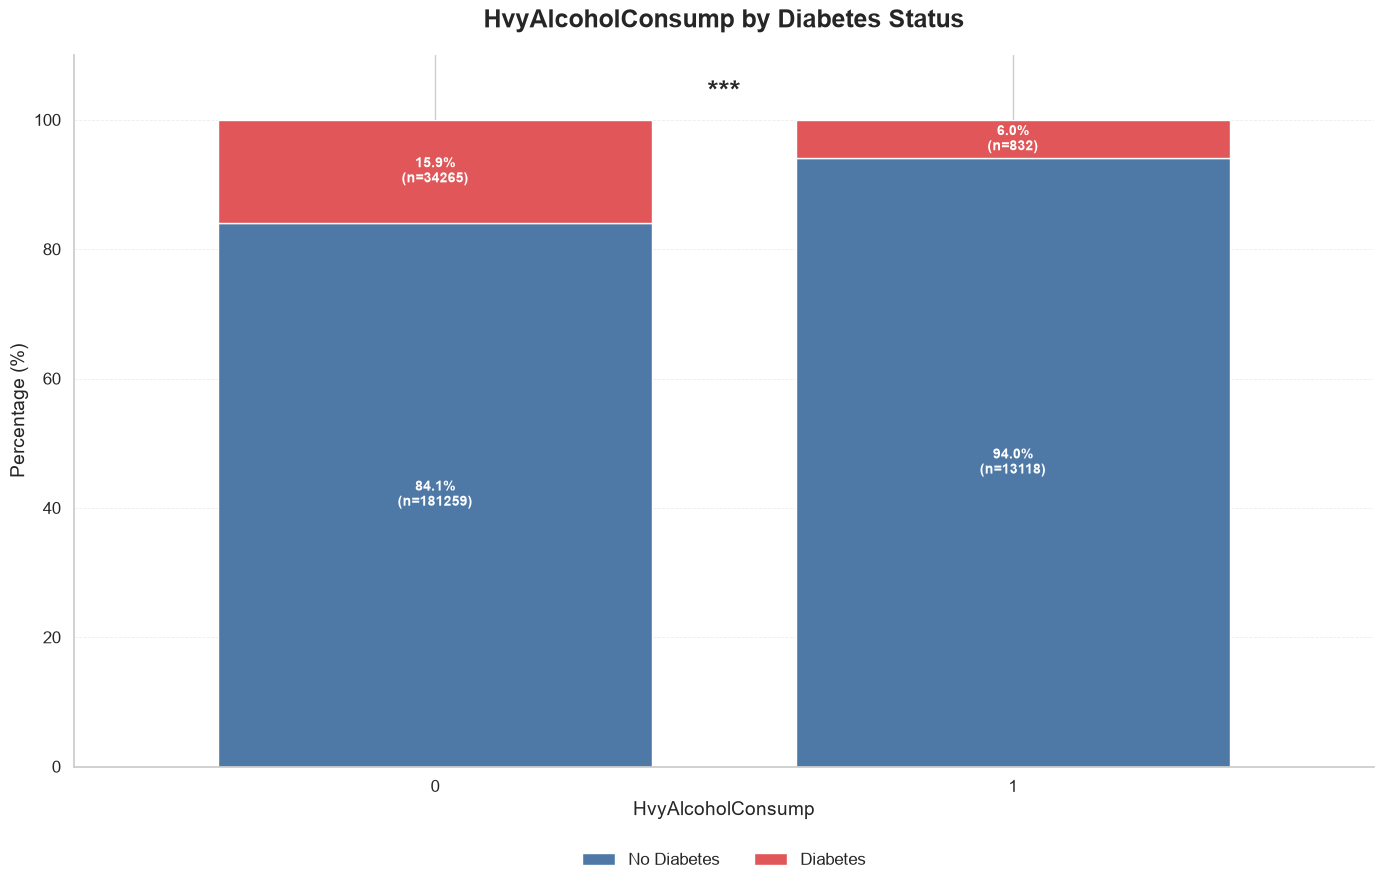

AnyHealthcare vs Diabetes_binary


Diabetes_binary,0,1
AnyHealthcare,,
0,10967,1422
1,183410,33675


Chi-square : 146.937
P-value    : 0.0000
Cramer's V : 0.025


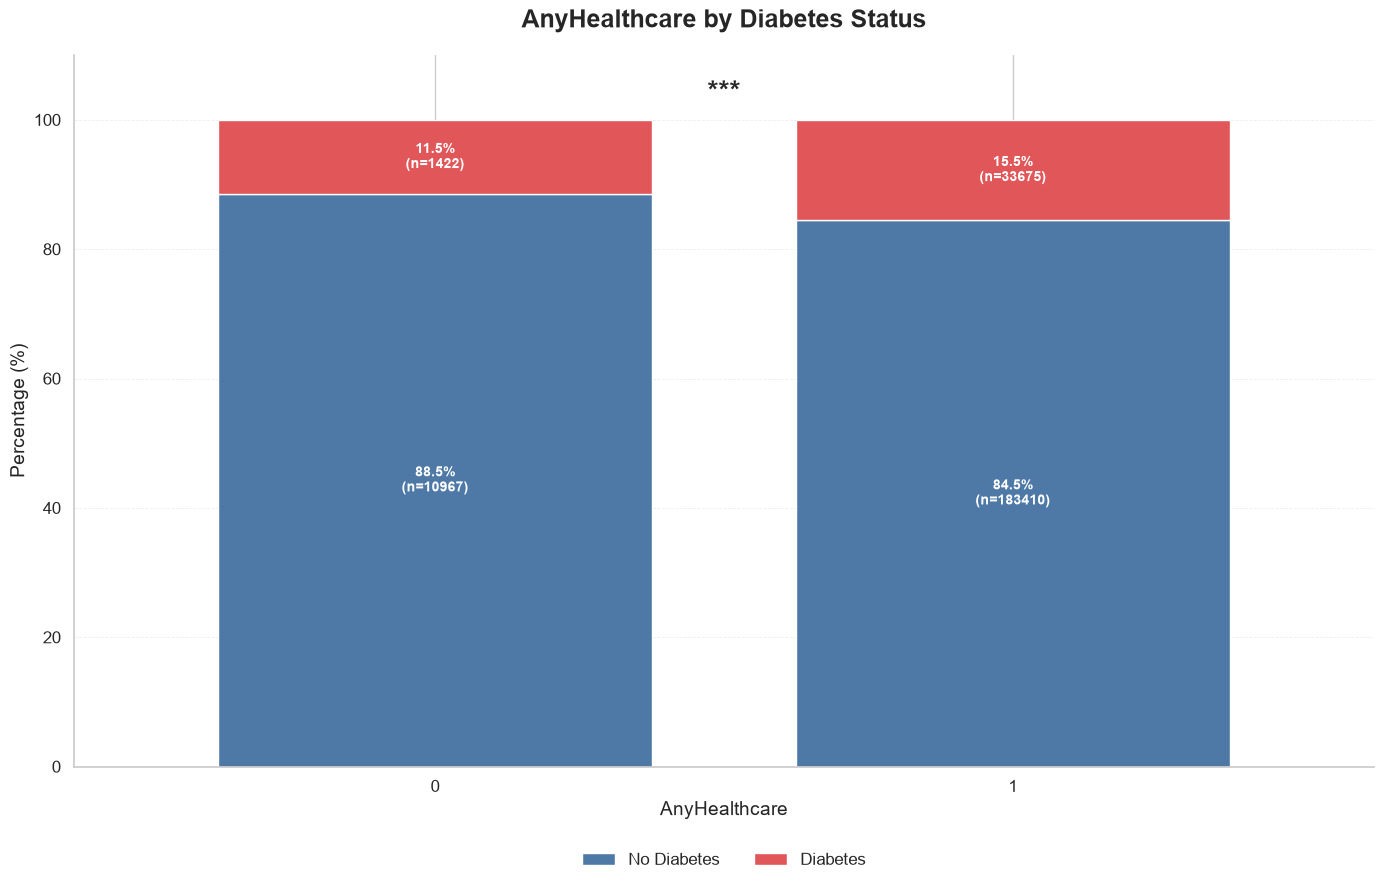

NoDocbcCost vs Diabetes_binary


Diabetes_binary,0,1
NoDocbcCost,,
0,176796,31355
1,17581,3742


Chi-square : 92.041
P-value    : 0.0000
Cramer's V : 0.020


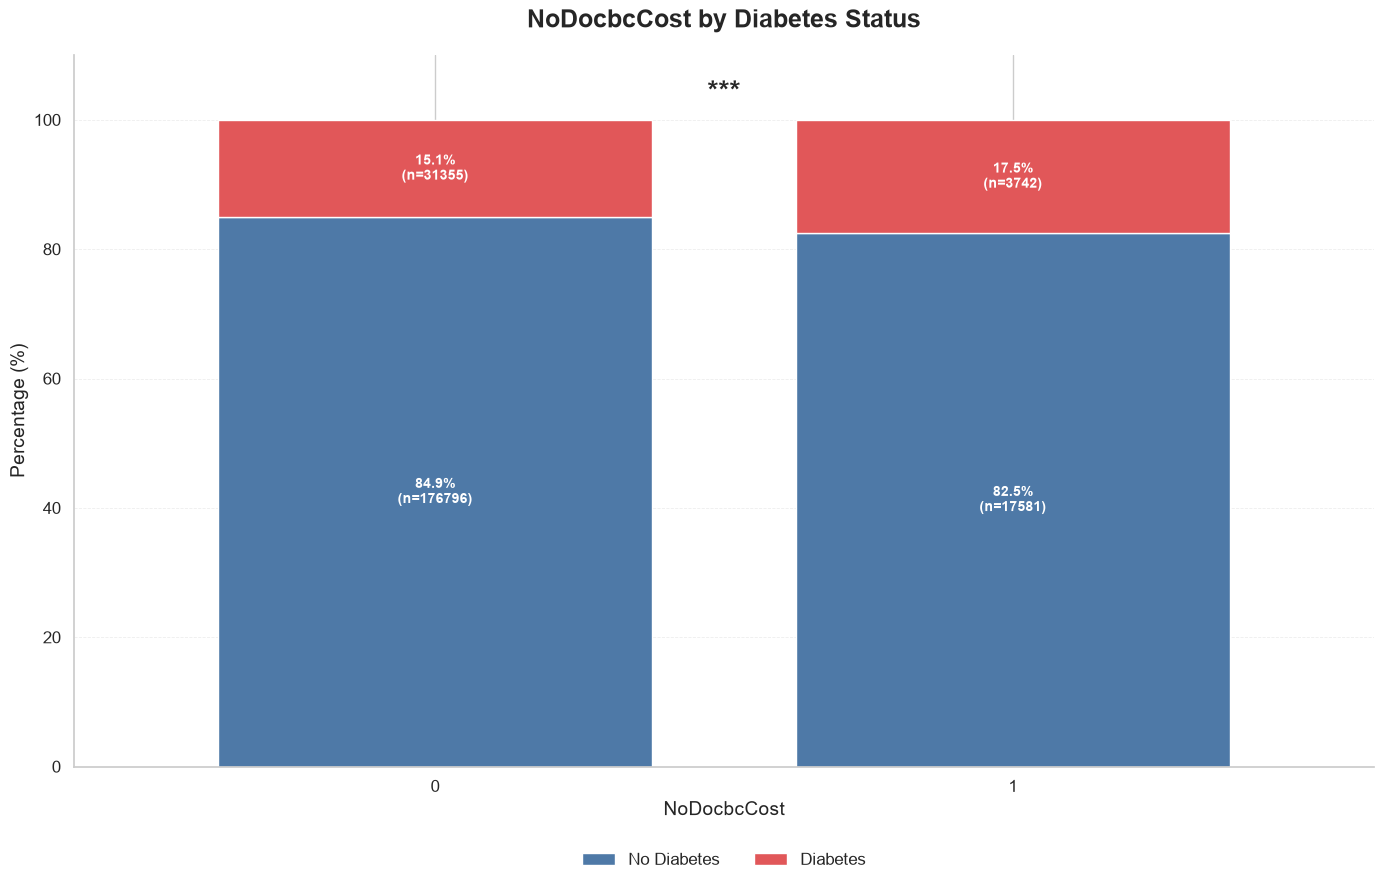

GenHlth vs Diabetes_binary


Diabetes_binary,0,1
GenHlth,,
1,33719,1135
2,71085,6280
3,60308,13324
4,21764,9781
5,7501,4577


Chi-square : 18193.704
P-value    : 0.0000
Cramer's V : 0.282


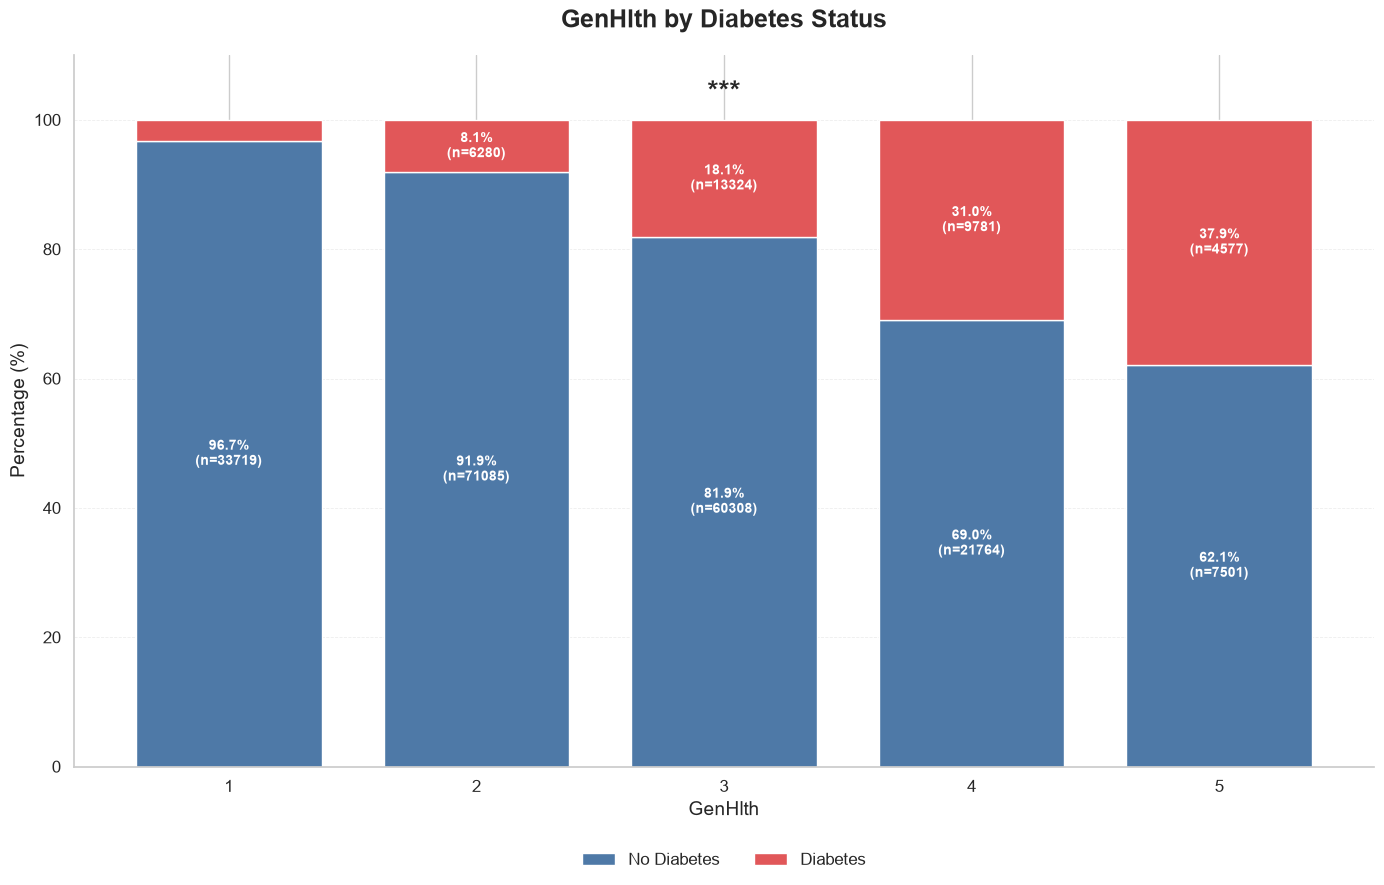

DiffWalk vs Diabetes_binary


Diabetes_binary,0,1
DiffWalk,,
0,164866,21983
1,29511,13114


Chi-square : 9670.630
P-value    : 0.0000
Cramer's V : 0.205


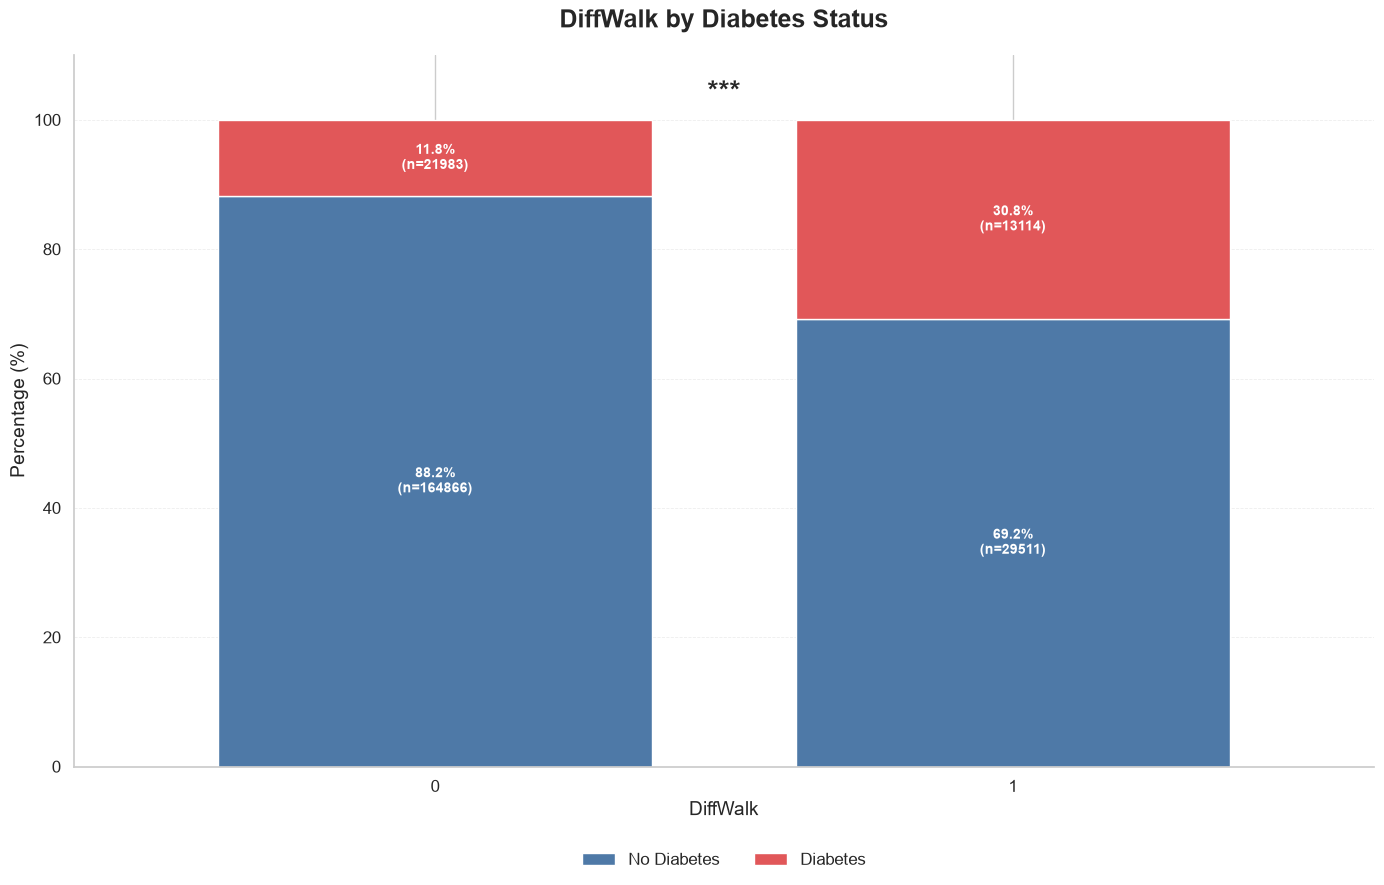

Sex vs Diabetes_binary


Diabetes_binary,0,1
Sex,,
0,110370,18345
1,84007,16752


Chi-square : 245.554
P-value    : 0.0000
Cramer's V : 0.033


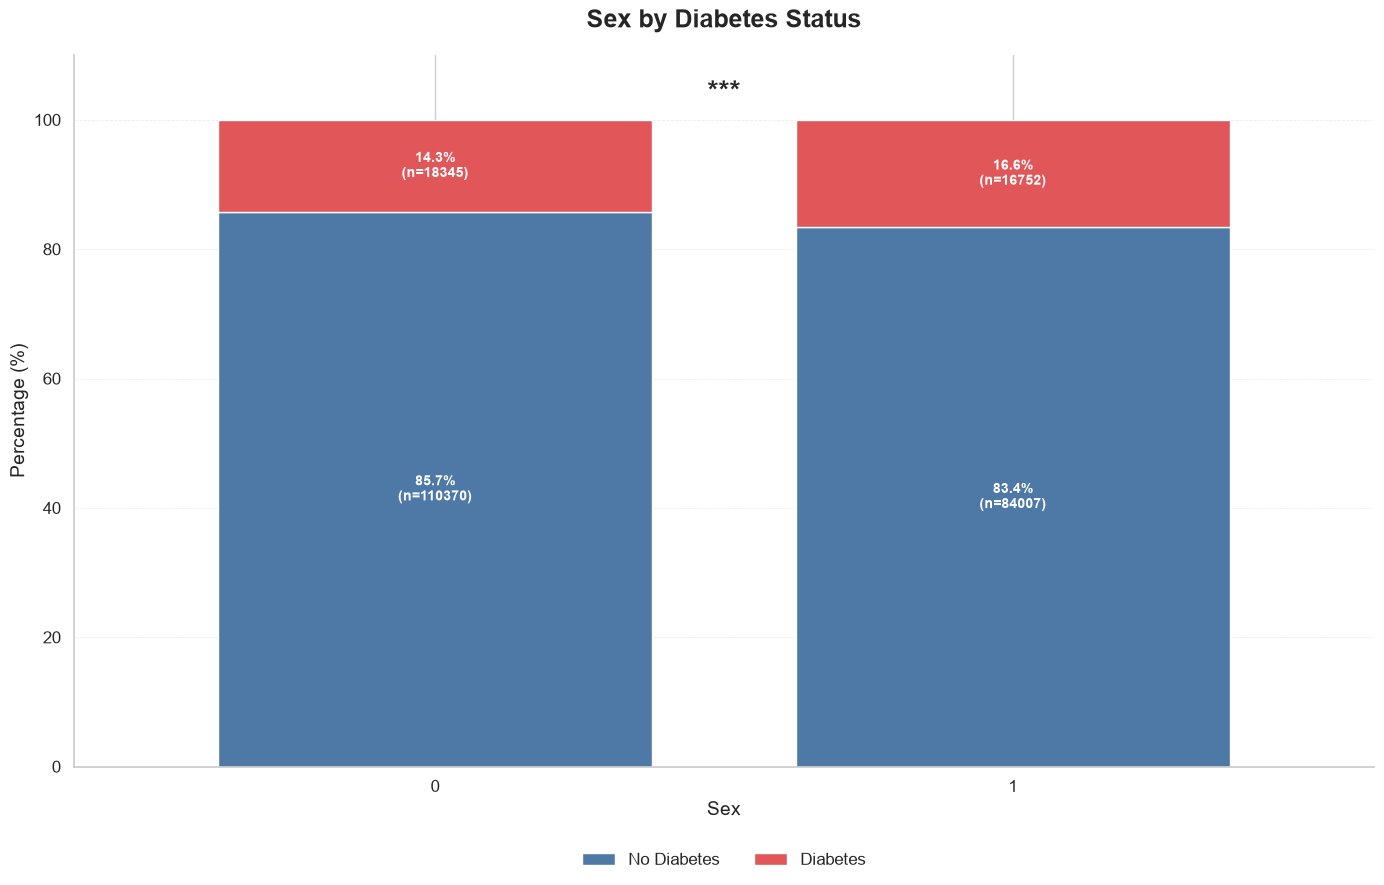

Age vs Diabetes_binary


Diabetes_binary,0,1
Age,,
1,5433,78
10,22610,6483
11,16903,5090
12,11996,3383
13,13591,3200
2,6924,140
3,9709,314
4,11604,625
5,12991,1049


Chi-square : 8207.832
P-value    : 0.0000
Cramer's V : 0.189


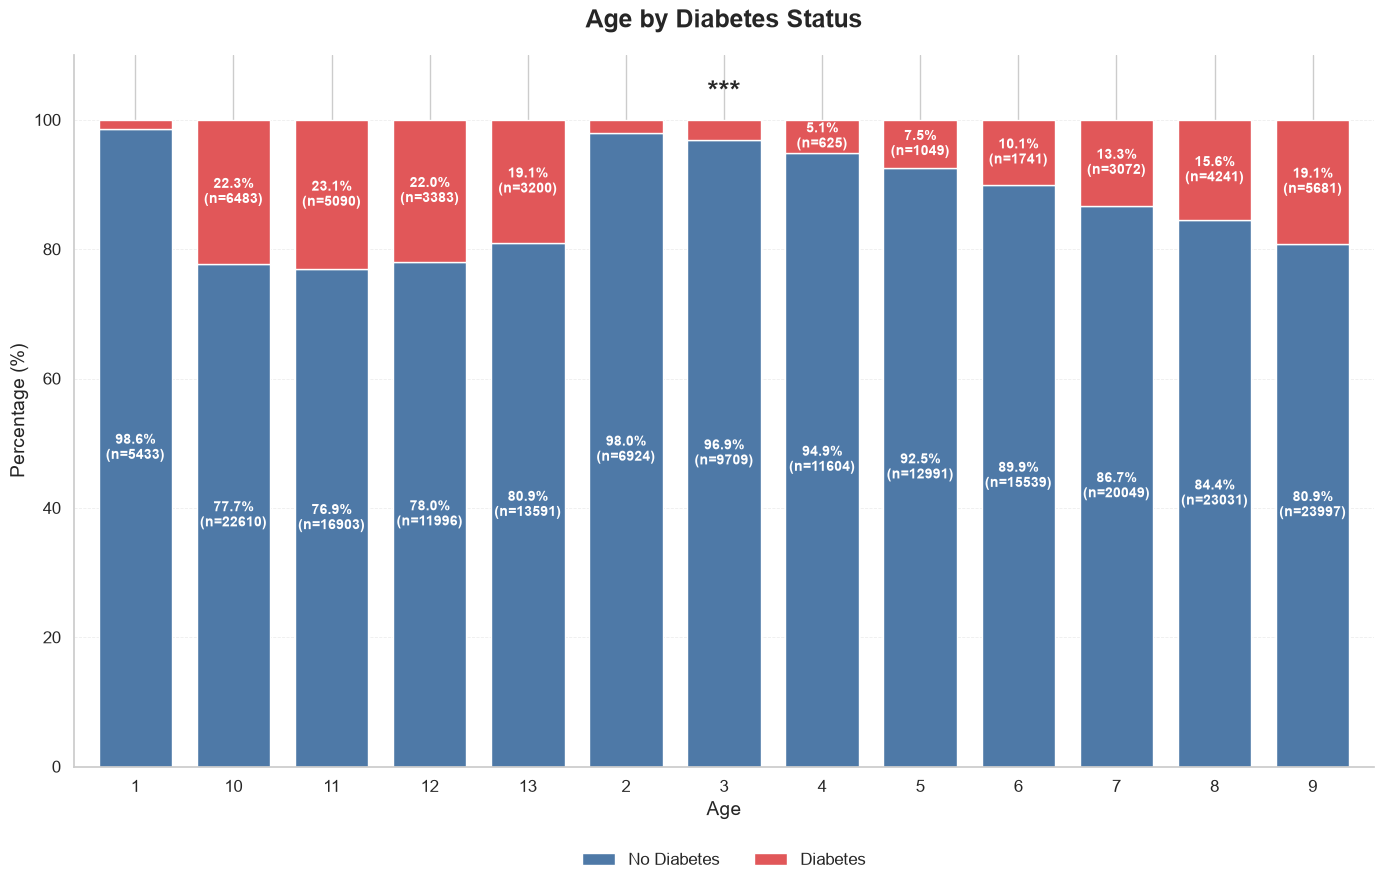

Education vs Diabetes_binary


Diabetes_binary,0,1
Education,,
1,127,47
2,2857,1183
3,7171,2296
4,50092,11032
5,56133,10311
6,77997,10228


Chi-square : 2508.405
P-value    : 0.0000
Cramer's V : 0.105


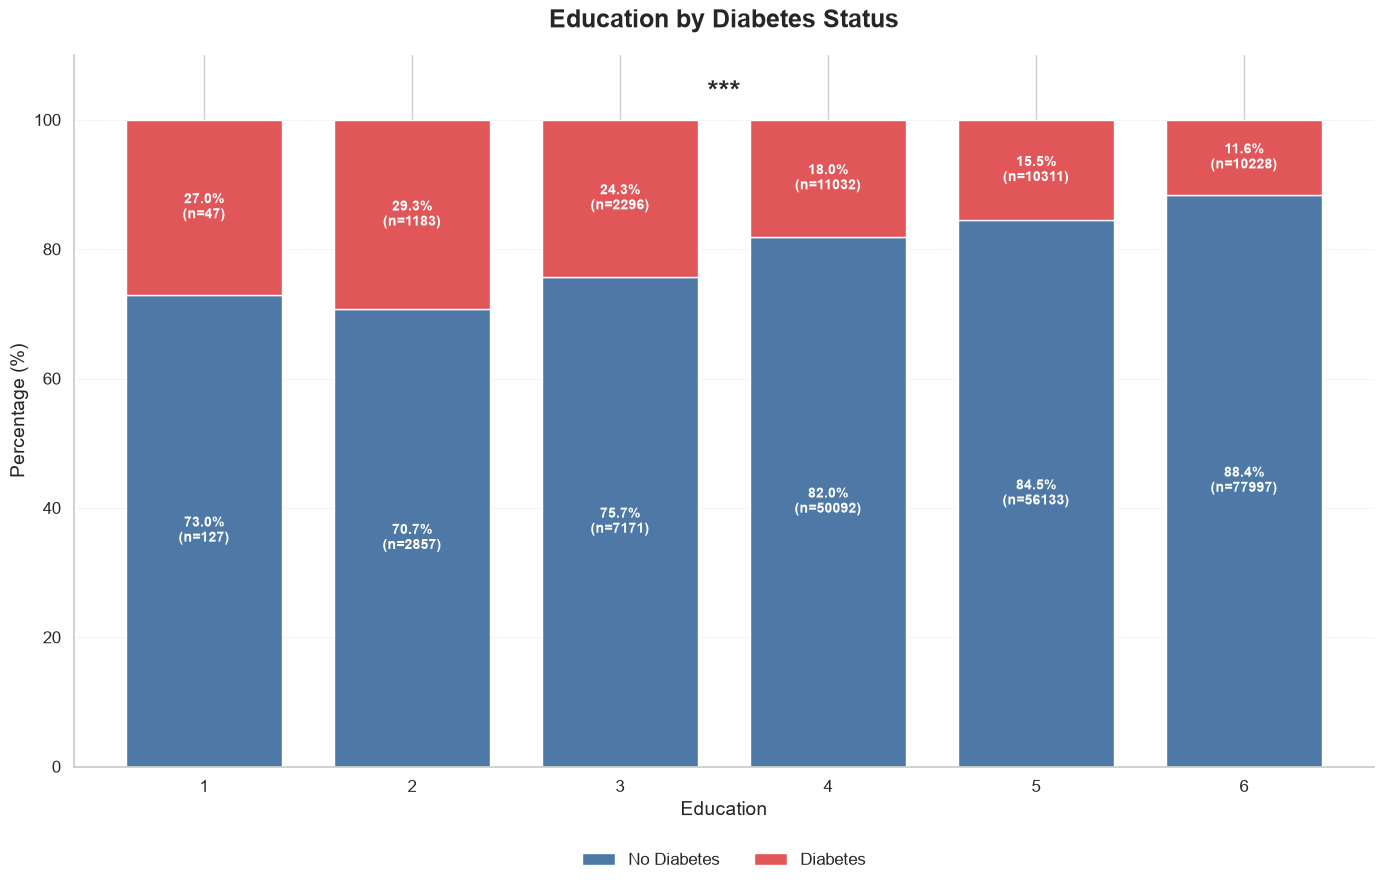

Income vs Diabetes_binary


Diabetes_binary,0,1
Income,,
1,7408,2383
2,8670,3086
3,12356,3564
4,15906,4047
5,20837,4489
6,29697,5260
7,34905,5226
8,64598,7042


Chi-square : 4637.196
P-value    : 0.0000
Cramer's V : 0.142


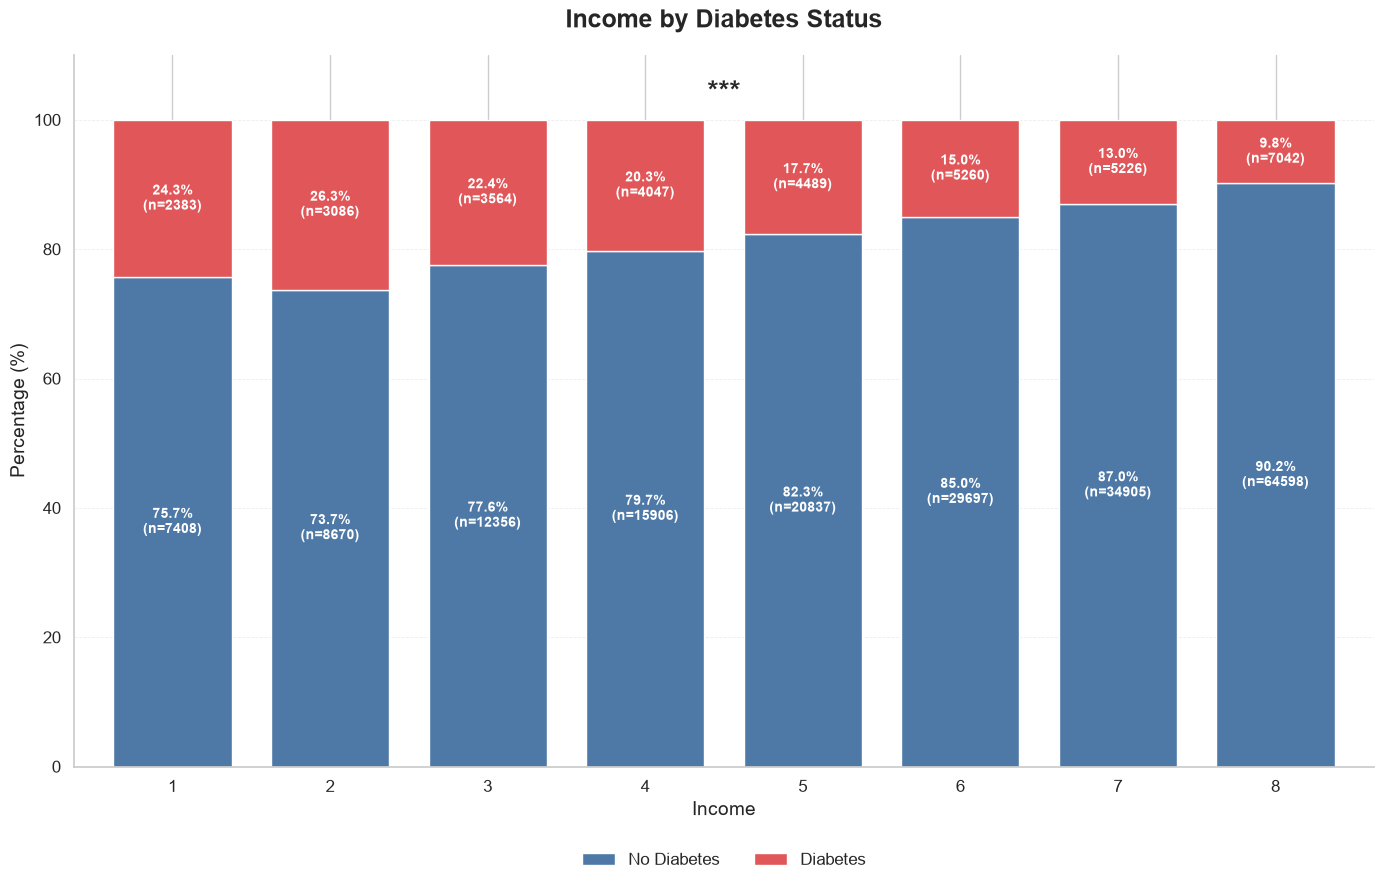

BMI_cat vs Diabetes_binary


Diabetes_binary,0,1
BMI_cat,,
Underweight,2883,169
Normal weight,68285,5350
Overweight,69995,11419
Obese,53214,18159


Chi-square : 9662.719
P-value    : 0.0000
Cramer's V : 0.205


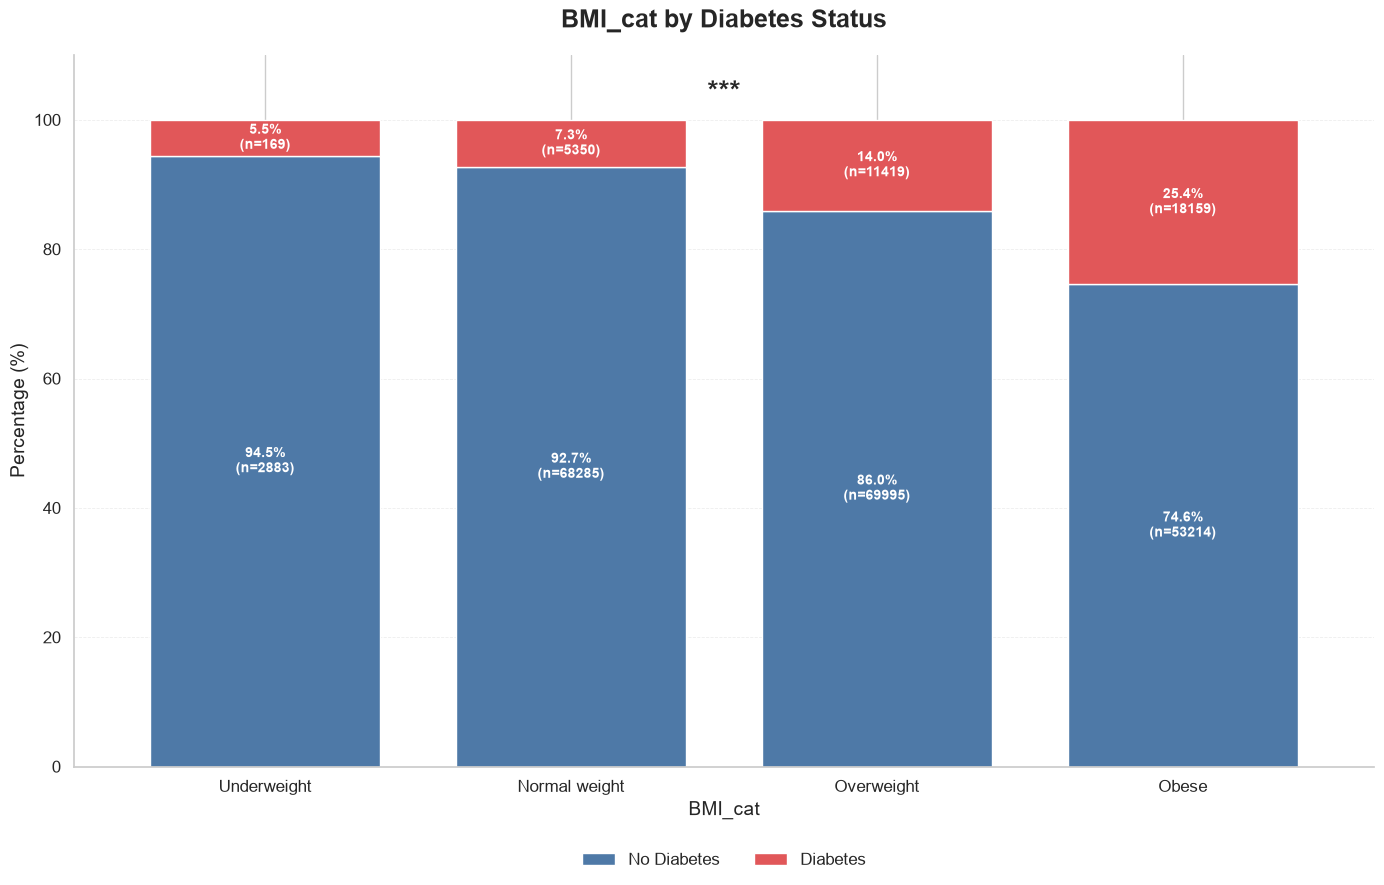

MentHlth_cat vs Diabetes_binary


Diabetes_binary,0,1
MentHlth_cat,,
0 days,129170,23155
1-10 days,45436,6711
11-20 days,8754,2011
21-30 days,11017,3220


Chi-square : 922.298
P-value    : 0.0000
Cramer's V : 0.063


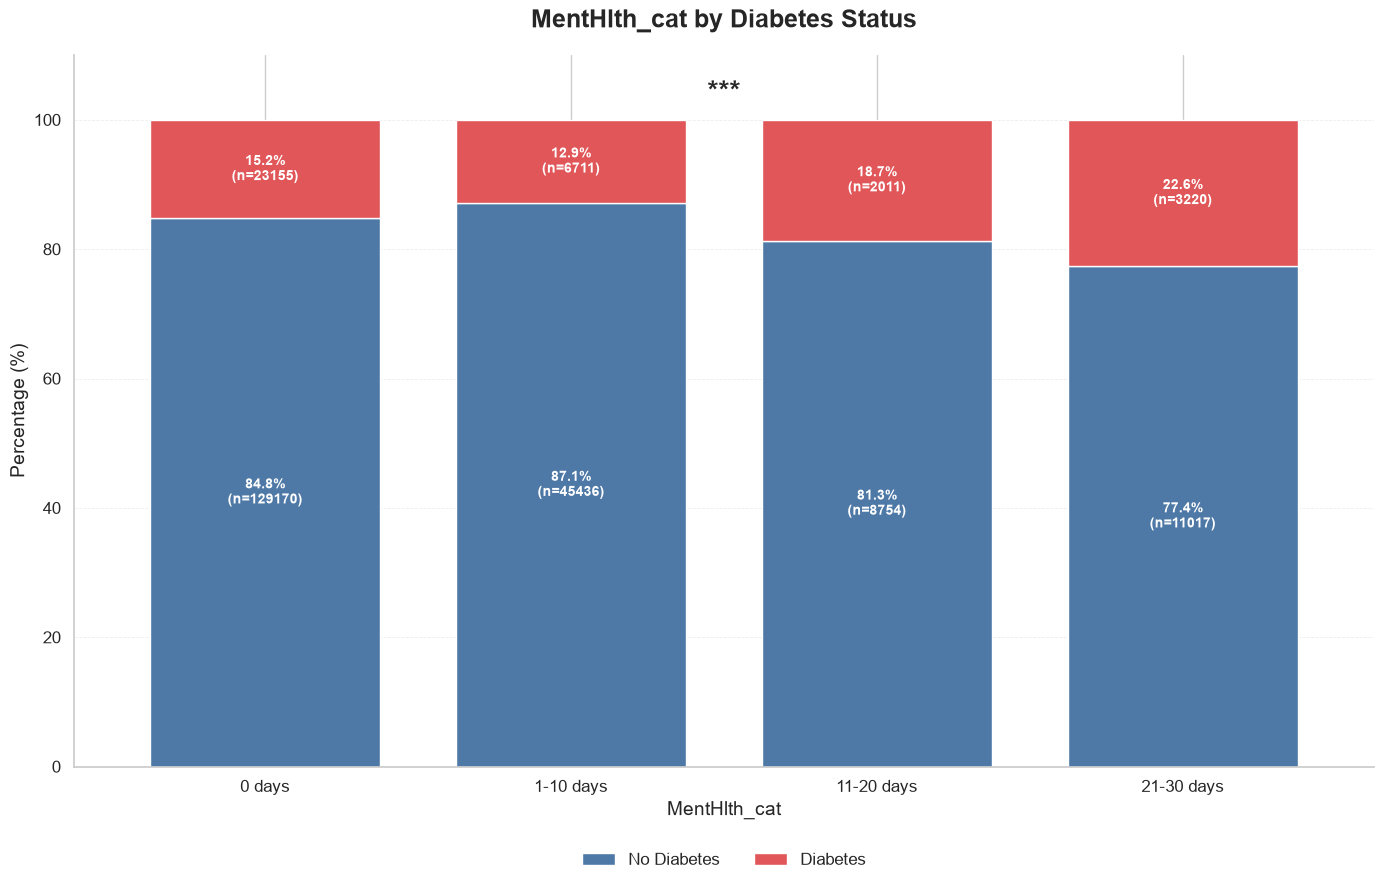

PhysHlth_cat vs Diabetes_binary


Diabetes_binary,0,1
PhysHlth_cat,,
0 days,120081,16497
1-10 days,49461,9089
11-20 days,8919,2940
21-30 days,15916,6571


Chi-square : 5284.650
P-value    : 0.0000
Cramer's V : 0.152


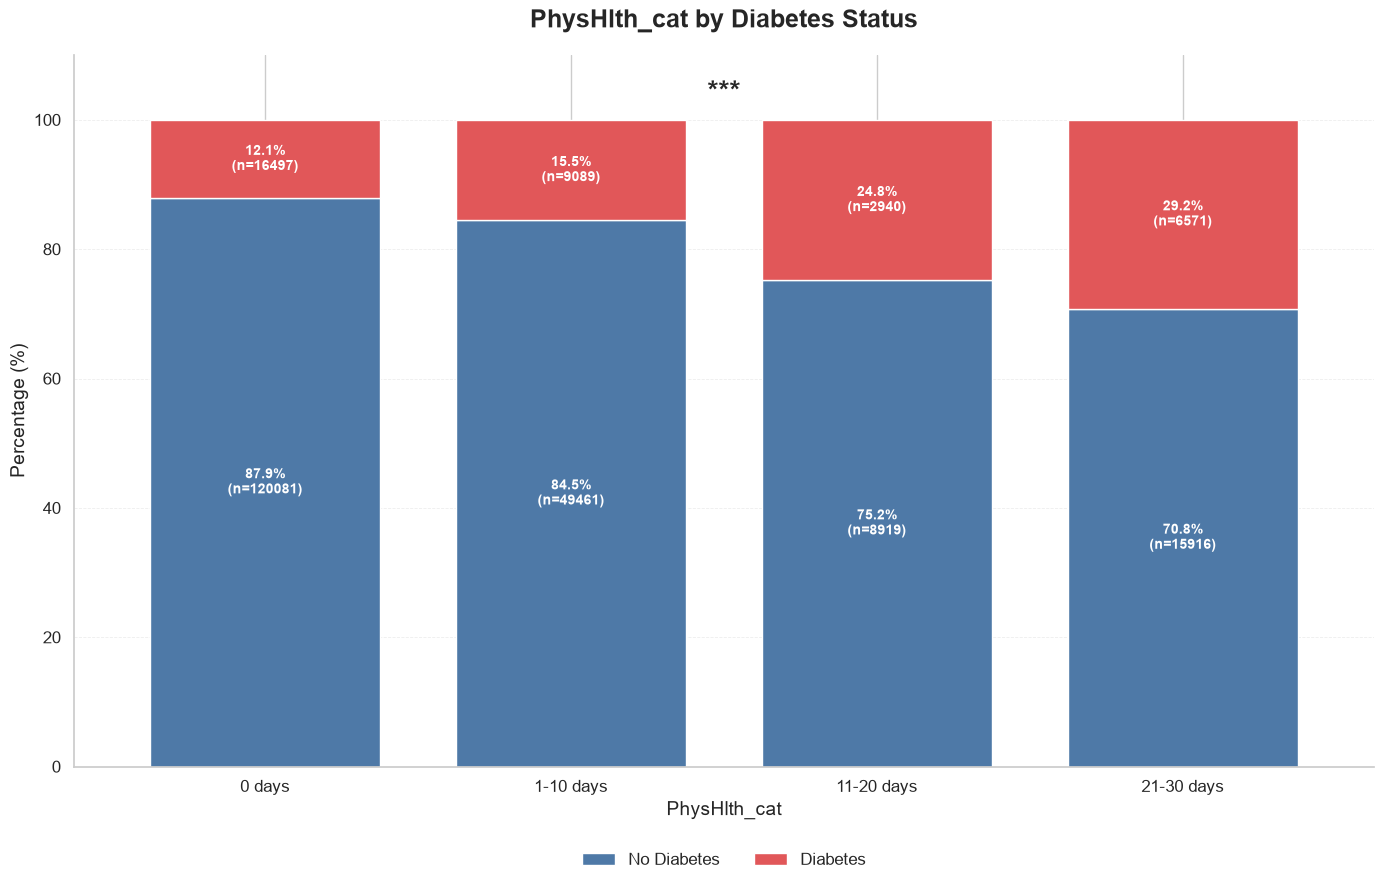

In [34]:
# ===============================================================
# Categorical Variables by Diabetes Status
# ===============================================================

for col in categorical_predictors:

    print("=" * 90)
    print(f"{col} vs {target}")
    print("=" * 90)

    # -----------------------------------------------------------
    # Summary Statistics
    # -----------------------------------------------------------

    contingency = pd.crosstab(

        df[col],

        df[target]

    )

    percent_table = (

        pd.crosstab(

            df[col],

            df[target],

            normalize="index"

        ) * 100

    )

    count_table = contingency.copy()

    display(contingency)

    # -----------------------------------------------------------
    # Chi-square Test
    # -----------------------------------------------------------

    chi2, p, dof, expected = chi2_contingency(

        contingency

    )

    # -----------------------------------------------------------
    # Cramer's V
    # -----------------------------------------------------------

    n = contingency.to_numpy().sum()

    r, k = contingency.shape

    cramers_v = np.sqrt(

        (chi2 / n)

        /

        min(r - 1, k - 1)

    )

    annotation = significance_label(p)

    print(f"Chi-square : {chi2:.3f}")

    print(f"P-value    : {p:.4f}")

    print(f"Cramer's V : {cramers_v:.3f}")

    # -----------------------------------------------------------
    # Store Results
    # -----------------------------------------------------------

    association_summary.append({

        "Variable": col,

        "Chi_square": round(chi2,3),

        "Degrees_of_Freedom": dof,

        "P_value": p,

        "Cramers_V": round(cramers_v,3),

        "Significance": annotation

    })

    # -----------------------------------------------------------
    # Figure
    # -----------------------------------------------------------

    fig, ax = plt.subplots(

        figsize=(14,9)

    )

    percent_table.plot(

        kind="bar",

        stacked=True,

        color=[

            diabetes_palette[c]

            for c in percent_table.columns

        ],

        width=0.75,

        ax=ax

    )

    # -----------------------------------------------------------
    # Bar Borders
    # -----------------------------------------------------------

    for container in ax.containers:

        for bar in container:

            bar.set_edgecolor("white")

            bar.set_linewidth(1)

    # -----------------------------------------------------------
    # Percentage Labels
    # -----------------------------------------------------------

    for i, category in enumerate(

        percent_table.index

    ):

        cumulative = 0

        for diabetes_status in percent_table.columns:

            pct = percent_table.loc[

                category,

                diabetes_status

            ]

            cnt = count_table.loc[

                category,

                diabetes_status

            ]

            if pct >= 5:

                ax.text(

                    i,

                    cumulative + pct/2,

                    f"{pct:.1f}%\n(n={cnt})",

                    ha="center",

                    va="center",

                    fontsize=10,

                    color="white",

                    fontweight="bold"

                )

            cumulative += pct

    # -----------------------------------------------------------
    # Significance
    # -----------------------------------------------------------

    if annotation != "ns":

        ax.text(

            (len(percent_table.index)-1)/2,

            103,

            annotation,

            fontsize=20,

            fontweight="bold",

            ha="center"

        )

    # -----------------------------------------------------------
    # Formatting
    # -----------------------------------------------------------

    ax.set_xlabel(col)

    ax.set_ylabel("Percentage (%)")

    ax.set_title(

        f"{col} by Diabetes Status",

        fontweight="bold",

        pad=20

    )

    ax.set_ylim(0,110)

    ax.tick_params(

        axis="x",

        rotation=0

    )

    ax.grid(

        axis="y",

        linestyle="--",

        linewidth=0.6,

        alpha=0.35

    )

    ax.set_axisbelow(True)

    sns.despine()

    ax.legend(

        [

            "No Diabetes",

            "Diabetes"

        ],

        loc="upper center",

        bbox_to_anchor=(0.5,-0.10),

        ncol=2,

        frameon=False

    )

    plt.tight_layout()

    save_figure(

        fig,

        DIABETES_DIR,

        f"{col}_Diabetes_Status.png"

    )

    plt.show()

    plt.close()

In [35]:
print(df[target].dtype)

print(df[target].unique())

category
['0', '1']
Categories (2, object): ['0', '1']


In [36]:
# ===============================================================
# Diabetes Association Summary
# ===============================================================

association_summary = pd.DataFrame(

    association_summary

)

association_summary = (

    association_summary

    .sort_values(

        by="Cramers_V",

        ascending=False

    )

)

display(

    association_summary

)

,Variable,Chi_square,Degrees_of_Freedom,P_value,Cramers_V,Significance
12,GenHlth,18193.704,4,0.000000e+00,0.282,***
0,HighBP,14840.422,1,0.000000e+00,0.254,***
13,DiffWalk,9670.630,1,0.000000e+00,0.205,***
18,BMI_cat,9662.719,3,0.000000e+00,0.205,***
1,HighChol,8719.657,1,0.000000e+00,0.195,***
15,Age,8207.832,12,0.000000e+00,0.189,***
5,HeartDiseaseorAttack,6491.586,1,0.000000e+00,0.168,***
20,PhysHlth_cat,5284.650,3,0.000000e+00,0.152,***
17,Income,4637.196,7,0.000000e+00,0.142,***
16,Education,2508.405,5,0.000000e+00,0.105,***


In [37]:
# ===============================================================
# Save Diabetes Association Summary
# ===============================================================

association_summary.to_csv(

    SUMMARY_DIR

    / "diabetes_association_summary.csv",

    index=False

)

print("="*70)

print("Diabetes association summary saved successfully.")

print("="*70)

Diabetes association summary saved successfully.


In [38]:
# ===============================================================
# Notebook Summary
# ===============================================================

print("=" * 70)
print("Exploratory Data Analysis Completed")
print("=" * 70)

print(f"Categorical variables analysed : {len(categorical_predictors)}")
print(f"Continuous variables analysed  : {len(continuous_cols)}")

print("\nGenerated outputs:")

print(f"\nFigures directory:")
print(EDA_DIR)

print(f"\nSummary tables directory:")
print(SUMMARY_DIR)

print("\nFiles created:")

for file in sorted(SUMMARY_DIR.glob("*.csv")):

    print(f"• {file.name}")

print("\nEDA completed successfully.")

Exploratory Data Analysis Completed
Categorical variables analysed : 21
Continuous variables analysed  : 3

Generated outputs:

Figures directory:
c:\Users\saifu\OneDrive\Documents\Python_Demo\Diabetes-Risk-Prediction\figures\EDA

Summary tables directory:
c:\Users\saifu\OneDrive\Documents\Python_Demo\Diabetes-Risk-Prediction\results\descriptive_statistics

Files created:
• categorical_summary.csv
• continuous_summary.csv
• diabetes_association_summary.csv

EDA completed successfully.
